### Project Description:

This project focuses on developing a real-time cascading failure mitigation system for power systems using Markov Decision Process (MDP)-based Reinforcement Learning (RL). Cascading failures can lead to widespread power outages, and this work aims to create an intelligent agent that can learn optimal strategies to prevent or minimize the impact of such events as they unfold.

Key aspects likely include:

*   **Power System Modeling:** Representing the power grid (e.g., using `pandapower`) as an environment for the RL agent.
*   **Reinforcement Learning:** Implementing RL algorithms (e.g., using `stable-baselines3`) to train an agent to make decisions (e.g., load shedding, generator rescheduling) that mitigate cascading failures.
*   **State and Action Space Design:** Defining the observable states of the power system and the available control actions for the RL agent.
*   **Reward Function Engineering:** Designing a reward mechanism that encourages the agent to maintain system stability and minimize failure consequences.
*   **Real-time Decision Making:** Developing a system capable of executing mitigation strategies in a timely manner.
*   **Simulation and Evaluation:** Testing the effectiveness of the RL agent in various failure scenarios (e.g., using `lightsim2grid`).

*INSTALLATION OF REQUIRED LIBRARIES*
pandapower
stable-baselines3
gymnasium
lightsim2grid
grid2op

Pandapower is a Python library for power system analysis and simulation. It allows engineers to model electrical grids and run calculations such as power flow and optimal power flow.

Main Uses in Your Project

Pandapower is used to:

Model the IEEE 14-bus power grid

Run power flow (PF)

Run optimal power flow (OPF)

Analyze line loading, voltage levels, and generator outputs

Detect islands in the grid

In [ ]:
!pip install pandapower

Stable-Baselines3 is a Python library that provides implementations of popular reinforcement learning algorithms.

It is built on PyTorch.

Algorithms Used in Your Project
Algorithm	Purpose
PPO	Proximal Policy Optimization
A2C	Advantage Actor-Critic

These algorithms train an agent to learn optimal actions for grid stability.

In [ ]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 3.6 MB/s eta 0:00:00


Gymnasium is a standard interface for reinforcement learning environments.

It defines how an RL agent interacts with an environment.

Gymnasium replaced the original OpenAI Gym.

In [ ]:
!pip install gymnasium

LightSim2Grid is a high-performance power flow simulator designed to accelerate Grid2Op environments.

It is written in C++ with Python bindings.

**Why It Is Used**

Pandapower can be slow for RL training because many power flows must be computed.

**LightSim2Grid provides:**

much faster power flow calculations

better performance for RL training

In [ ]:
!pip install lightsim2grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 22.2 MB/s eta 0:00:00


Grid2Op is a reinforcement learning environment specifically designed for power grid control problems.

**It simulates:**

power grid operations

cascading failures

line switching

generator control



**Grid2Op provides:**

the environment where the RL agent interacts

grid states (observations)

reward signals

cascading failure simulation

In [ ]:
!pip install grid2op

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.6/18.6 MB 79.1 MB/s eta 0:00:00


*IMPORTING REQUIRED MODULES*

In [ ]:
import pandapower as pp
import stable_baselines3 as sb3
import gymnasium as gym
import lightsim2grid as l2g
import numpy as np
import pandas as pd
import torch
import grid2op
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from grid2op.gym_compat import GymEnv
from stable_baselines3 import PPO, A2C

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import warnings
warnings.filterwarnings("ignore")

*STEP-1 : CREATE POWERGRID ENVIRONMENT*
[Make.py]

In [ ]:
# Copyright (c) 2019-2021, RTE (https://www.rte-france.com)
# See AUTHORS.txt
# This Source Code Form is subject to the terms of the Mozilla Public License, version 2.0.
# If a copy of the Mozilla Public License, version 2.0 was not distributed with this file,
# you can obtain one at http://mozilla.org/MPL/2.0/.
# SPDX-License-Identifier: MPL-2.0
# This file is part of Grid2Op, Grid2Op a testbed platform to model sequential decision making in power systems.

import time
import os
import warnings
from typing import Union, Optional
import logging

from grid2op.Environment import Environment
from grid2op.MakeEnv.MakeFromPath import make_from_dataset_path, ERR_MSG_KWARGS
from grid2op.Exceptions import Grid2OpException, UnknownEnv
import grid2op.MakeEnv.PathUtils
from grid2op.MakeEnv.PathUtils import _create_path_folder
from grid2op.MakeEnv._aux_var import TEST_DEV_ENVS
from grid2op.Download.DownloadDataset import _aux_download
from grid2op.Space import DEFAULT_ALLOW_DETACHMENT, DEFAULT_N_BUSBAR_PER_SUB

_VAR_FORCE_TEST = "_GRID2OP_FORCE_TEST"

_REQUEST_FAIL_EXHAUSTED_ERR = (
    'Impossible to retrieve data at "{}".\n'
    "If the problem persists, please contact grid2op developers by sending an issue at "
    "https://github.com/Grid2Op/grid2op/issues"
)
_REQUEST_FAIL_RETRY_ERR = (
    'Failure to get a response from the url "{}".\n'
    "Retrying... {} attempt(s) remaining"
)
_REQUEST_EXCEPT_RETRY_ERR = (
    'Exception in getting an answer from "{}".\n' "Retrying... {} attempt(s) remaining"
)

_LIST_REMOTE_URL = (
    "https://api.github.com/repos/Grid2Op/grid2op-datasets/contents/datasets.json"
)
_LIST_REMOTE_KEY = "download_url"
_LIST_REMOTE_INVALID_CONTENT_JSON_ERR = (
    "Impossible to retrieve available datasets. "
    "File could not be converted to json. "
    "Parsing error:\n {}"
)
_LIST_REMOTE_CORRUPTED_CONTENT_JSON_ERR = (
    "Corrupted json retrieved from github api. "
    "Please wait a few minutes and try again. "
    "If the error persist, contact grid2op devs by making an issue at "
    "\n\thttps://github.com/Grid2Op/grid2op/issues/new/choose"
)
_LIST_REMOTE_INVALID_DATASETS_JSON_ERR = (
    "Impossible to retrieve available datasets. "
    "File could not be converted to json. "
    'The error was \n"{}"'
)

_FETCH_ENV_UNKNOWN_ERR = (
    'Impossible to find the environment named "{}".\n'
    "Current available environments are:\n{}"
)

_MULTIMIX_FILE = ".multimix"

_MAKE_DEV_ENV_WARN = (
    "You are using a development environment. "
    "This environment is not intended for training agents. It might not be up to date "
    'and its primary use if for tests (hence the "test=True" you passed as argument). '
    "Use at your own risk."
)
_MAKE_DEV_ENV_DEPRECATED_WARN = (
    'Dev env "{}" has been deprecated '
    "and will be removed in future version.\n"
    'Please update to dev envs starting by "rte" or "l2rpn"'
)
_MAKE_FIRST_TIME_WARN = (
    'It is the first time you use the environment "{}".\n'
    "We will attempt to download this environment from remote"
)
_MAKE_UNKNOWN_ENV = 'Impossible to load the environment named "{}".'

_EXTRACT_DS_NAME_CONVERT_ERR = (
    'The "dataset_name" argument '
    "should be convertible to string, "
    'but "{}" was provided.'
)
_EXTRACT_DS_NAME_RECO_ERR = (
    'Impossible to recognize the environment name from path "{}"'
)

def _force_test_dataset():
    res = False
    if _VAR_FORCE_TEST in os.environ:
        try:
            var_int = int(os.environ[_VAR_FORCE_TEST])
        except Exception as exc_:
            warnings.warn(f"The environment variable {_VAR_FORCE_TEST}, "
                          f"used to force the \"test=True\" in grid2op "
                          f"cannot be converted to an integer with error "
                          f"\"{exc_}\". As it is set nonetheless, we "
                          f"assume you want to force \"test=True\".")
            var_int = 1
        res = var_int >= 1
    return res

def _send_request_retry(url, nb_retry=10, gh_session=None):
    """
    INTERNAL

    .. warning:: /!\\\\ Internal, do not use unless you know what you are doing /!\\\\
    """
    if nb_retry <= 0:
        raise Grid2OpException(_REQUEST_FAIL_EXHAUSTED_ERR.format(url))

    if gh_session is None:
        import requests
        gh_session = requests.Session()

    try:
        response = gh_session.get(url=url)
        if response.status_code == 200:
            return response
        warnings.warn(_REQUEST_FAIL_RETRY_ERR.format(url, nb_retry - 1))
        time.sleep(1)
        return _send_request_retry(url, nb_retry=nb_retry - 1, gh_session=gh_session)
    except Grid2OpException:
        raise
    except KeyboardInterrupt:
        raise
    except Exception as exc_:
        warnings.warn(_REQUEST_EXCEPT_RETRY_ERR.format(url, nb_retry - 1))
        time.sleep(1)
        return _send_request_retry(url, nb_retry=nb_retry - 1, gh_session=gh_session)


def _retrieve_github_content(url, is_json=True):
    answer = _send_request_retry(url)
    try:
        answer_json = answer.json()
    except Exception as e:
        raise Grid2OpException(_LIST_REMOTE_INVALID_CONTENT_JSON_ERR.format(e))

    if _LIST_REMOTE_KEY not in answer_json:
        raise Grid2OpException(_LIST_REMOTE_CORRUPTED_CONTENT_JSON_ERR)
    time.sleep(1)
    avail_datasets = _send_request_retry(answer_json[_LIST_REMOTE_KEY])
    if is_json:
        try:
            res = avail_datasets.json()
        except Exception as e:
            raise Grid2OpException(_LIST_REMOTE_INVALID_DATASETS_JSON_ERR.format(e))
    else:
        res = avail_datasets.text
    return res


def _list_available_remote_env_aux():
    return _retrieve_github_content(url=_LIST_REMOTE_URL)


def _fecth_environments(dataset_name):
    avail_datasets_json = _list_available_remote_env_aux()
    if not dataset_name in avail_datasets_json:
        known_ds = sorted(avail_datasets_json.keys())
        raise UnknownEnv(_FETCH_ENV_UNKNOWN_ERR.format(dataset_name, known_ds))
    # url = _FETCH_ENV_TAR_URL.format(avail_datasets_json[dataset_name], dataset_name)
    dict_ = avail_datasets_json[dataset_name]
    baseurl, filename = dict_["base_url"], dict_["filename"]
    url = baseurl + filename
    # name is "tar.bz2" so i need to get rid of 2 extensions
    ds_name_dl = os.path.splitext(os.path.splitext(filename)[0])[0]
    return url, ds_name_dl


def _extract_ds_name(dataset_path):
    """
    If a path is provided, clean it to have a proper datasetname.

    If a dataset name is already provided, then i just returns it.

    Parameters
    ----------
    dataset_path: ``str``
        The path in the form of a

    Returns
    -------
    dataset_name: ``str``
        The name of the dataset (all lowercase, without "." etc.)

    """

    try:
        dataset_path = str(dataset_path)
    except Exception as exc_:
        raise Grid2OpException(
            _EXTRACT_DS_NAME_CONVERT_ERR.format(dataset_path)
        ) from exc_

    try:
        dataset_name = os.path.split(dataset_path)[-1]
    except Exception as exc_:
        raise UnknownEnv(_EXTRACT_DS_NAME_RECO_ERR.format(dataset_path)) from exc_
    dataset_name = dataset_name.lower().rstrip().lstrip()
    dataset_name = os.path.splitext(dataset_name)[0]
    return dataset_name


def _aux_is_multimix(dataset_path):
    if os.path.exists(os.path.join(dataset_path, _MULTIMIX_FILE)):
        return True
    return False


def _aux_make_multimix(
    dataset_path,
    test=False,
    experimental_read_from_local_dir=False,
    n_busbar=DEFAULT_N_BUSBAR_PER_SUB,
    allow_detachment=DEFAULT_ALLOW_DETACHMENT,
    _add_cls_nm_bk=True,
    _add_to_name="",
    _compat_glop_version=None,
    _overload_name_multimix=None,
    logger=None,
    **kwargs
) -> Environment:
    # Local import to prevent imports loop
    from grid2op.Environment import MultiMixEnvironment
    if _overload_name_multimix is not None:
        raise RuntimeError("You should not create a MultiMix with `_overload_name_multimix`.")
    return MultiMixEnvironment(
        dataset_path,
        experimental_read_from_local_dir=experimental_read_from_local_dir,
        n_busbar=n_busbar,
        allow_detachment=allow_detachment,
        _test=test,
        _add_cls_nm_bk=_add_cls_nm_bk,
        _add_to_name=_add_to_name,
        _compat_glop_version=_compat_glop_version,
        logger=logger,
        **kwargs
    )


def _get_path_multimix(_overload_name_multimix) -> str:
    baseenv_path, multi_mix_name, add_to_name = _overload_name_multimix
    if os.path.exists(baseenv_path):
        return baseenv_path
    if multi_mix_name in TEST_DEV_ENVS:
        return TEST_DEV_ENVS[multi_mix_name]
    raise Grid2OpException(f"Unknown multimix environment with name {multi_mix_name} that should be located at {baseenv_path}.")


def make(
    dataset : Union[str, os.PathLike],
    *,
    test : bool=False,
    logger: Optional[logging.Logger]=None,
    experimental_read_from_local_dir : bool=False,
    n_busbar=DEFAULT_N_BUSBAR_PER_SUB,
    allow_detachment=DEFAULT_ALLOW_DETACHMENT,
    _add_cls_nm_bk=True,
    _add_to_name : str="",
    _compat_glop_version : Optional[str]=None,
    _overload_name_multimix : Optional[str]=None,  # do not use !
    **kwargs
) -> Environment:
    """
    This function is a shortcut to rapidly create some (pre defined) environments within the grid2op framework.

    Other environments, with different powergrids will be made available in the future and will be easily downloadable
    using this function.

    It mimic the `gym.make` function.

    .. versionchanged:: 1.9.3
        Remove the possibility to use this function with arguments (force kwargs)

    .. versionadded:: 1.10.0
        The `n_busbar` parameters

    .. versionadded:: 1.11.0
        The `allow_detachment` parameter

    .. danger::
        The :func:`grid2op.make` function can execute arbitrary code. Do not attempt
        to "make" an environment for which you don't trust (or even know) the authors.

    Parameters
    ----------

    dataset: ``str`` or path
        Name of the environment you want to create

    test: ``bool``
        Whether you want to use a test environment (**NOT** recommended). Use at your own risk.

    logger:
        If you want to use a specific logger for environment and all other
        grid2op objects, you can put it here. This feature is still under development.

    experimental_read_from_local_dir: ``bool``
        Grid2op "embed" the grid description into the description of the classes
        themselves. By default this is done "on the fly" (when the environment is created)
        but for some usecase (especially ones involving multiprocessing or "pickle")
        it might not be easily usable. If you encounter issues with pickle or multi
        processing, you can set this flag to ``True``. See the doc of
        :func:`grid2op.Environment.BaseEnv.generate_classes` for more information.

    n_busbar: ``int``
        Number of independant busbars allowed per substations. By default it's 2.

    allow_detachment: ``bool``
        Whether to allow loads and generators to be shed without a game over. By default it's False.

    kwargs:
        Other keyword argument to give more control on the environment you are creating. See
        the Parameters information of the :func:`make_from_dataset_path`.

    _add_cls_nm_bk: ``bool``
        Internal (and new in version 1.11.0). This flag (True by default, which is a breaking
        change from 1.11.0 compared to previous versions) will add the backend
        name in the generated class name.

        It is deactivated if classes are automatically generated by default `use_class_in_files`
        is ``True``

    _add_to_name:
        Internal, do not use (and can only be used when setting "test=True"). If
        `experimental_read_from_local_dir` is set to True, this has no effect.

    _compat_glop_version:
        Internal, do not use (and can only be used when setting "test=True")

    _overload_name_multimix:
        Internal, do not use !

    Returns
    -------
    env: :class:`grid2op.Environment.Environment`
        The created environment.

    Examples
    --------

    If you want to create the environment "l2rpn_case14_sandbox":

    .. code-block: python

        import grid2op
        env_name = "l2rpn_case14_sandbox"  # or any other supported environment
        env = grid2op.make(env_name)
        # env implements the openai gym interface (env.step, env.render, env.reset etc.)

    **NB** the first time you type this command, the dataset (approximately 300 MB for this one) will be
    downloaded from the internet, sizes vary per dataset.

    """
    if _force_test_dataset():
        if not test:
            warnings.warn(f"The environment variable \"{_VAR_FORCE_TEST}\" is defined so grid2op will be forced in \"test\" mode. "
                          f"This is equivalent to pass \"grid2op.make(..., test=True)\" and prevents any download of data.")
            test = True

    if dataset is None:
        raise Grid2OpException("Impossible to create an environment without its name. Please call something like: \n"
                               "> env = grid2op.make('l2rpn_case14_sandbox') \nor\n"
                               "> env = grid2op.make('rte_case14_realistic')")
    try:
        n_busbar_int = int(n_busbar)
    except Exception as exc_:
        raise Grid2OpException("n_busbar parameters should be convertible to integer") from exc_

    if n_busbar != n_busbar_int:
        raise Grid2OpException(f"n_busbar parameters should be convertible to integer, but we have "
                               f"int(n_busbar) = {n_busbar_int} != {n_busbar}")


    accepted_kwargs = ERR_MSG_KWARGS.keys() | {"dataset", "test"}
    for el in kwargs:
        if el not in accepted_kwargs:
            raise Grid2OpException(
                'The keyword argument "{}" you provided is invalid. Possible keyword '
                'arguments to create environments are "{}".'
                "".format(el, sorted(accepted_kwargs))
            )
    # Select how to create the environment:
    # Default with make from path
    make_from_path_fn = make_from_dataset_path

    # dataset arg is a valid path: load it
    if os.path.exists(dataset):
        # check if its a test environment
        if test:
            _add_to_name_tmp = _add_to_name
            _compat_glop_version_tmp = _compat_glop_version
            test_tmp = True
        else:
            _add_to_name_tmp = ""
            _compat_glop_version_tmp = None
            test_tmp = False

        # Check if multimix from path
        if _aux_is_multimix(dataset) and not test_tmp:
            make_from_path_fn = _aux_make_multimix
        elif _aux_is_multimix(dataset) and test_tmp:

            def make_from_path_fn_(*args, **kwargs):
                if not "logger" in kwargs:
                    kwargs["logger"] = logger
                if not "experimental_read_from_local_dir" in kwargs:
                    kwargs[
                        "experimental_read_from_local_dir"
                    ] = experimental_read_from_local_dir
                return _aux_make_multimix(*args, test=True, **kwargs)

            make_from_path_fn = make_from_path_fn_

        if not "logger" in kwargs:
            kwargs["logger"] = logger
        if not "experimental_read_from_local_dir" in kwargs:
            kwargs[
                "experimental_read_from_local_dir"
            ] = experimental_read_from_local_dir

        return make_from_path_fn(
            dataset_path=dataset,
            _add_cls_nm_bk=_add_cls_nm_bk,
            _add_to_name=_add_to_name_tmp,
            _compat_glop_version=_compat_glop_version_tmp,
            _overload_name_multimix=_overload_name_multimix,
            n_busbar=n_busbar,
            allow_detachment=allow_detachment,
            **kwargs
        )

    # Not a path: get the dataset name and cache path
    dataset_name = _extract_ds_name(dataset)
    real_ds_path = os.path.join(
        grid2op.MakeEnv.PathUtils.DEFAULT_PATH_DATA, dataset_name
    )

    # Unknown dev env
    if _overload_name_multimix is None and test and dataset_name not in TEST_DEV_ENVS:
        raise Grid2OpException(_MAKE_UNKNOWN_ENV.format(dataset))

    # Known test env and test flag enabled
    if test:
        warnings.warn(_MAKE_DEV_ENV_WARN)
        # Warning for deprecated dev envs
        if not (
            dataset_name.startswith("rte")
            or dataset_name.startswith("l2rpn")
            or dataset_name.startswith("educ")
        ):
            warnings.warn(_MAKE_DEV_ENV_DEPRECATED_WARN.format(dataset_name))
        if _overload_name_multimix:
            # make is invoked from a Multimix
            path_multimix = _get_path_multimix(_overload_name_multimix)
            ds_path = os.path.join(path_multimix, dataset_name)
        else:
            # normal behaviour
            ds_path = TEST_DEV_ENVS[dataset_name]
        # Check if multimix from path
        if _aux_is_multimix(ds_path):

            def make_from_path_fn_(*args, **kwargs):
                if "logger" not in kwargs:
                    kwargs[
                        "logger"
                    ] = logger  # foward the logger if not present already
                return _aux_make_multimix(*args, test=True, **kwargs)

            make_from_path_fn = make_from_path_fn_

        return make_from_path_fn(
            dataset_path=ds_path,
            logger=logger,
            n_busbar=n_busbar,
            allow_detachment=allow_detachment,
            _add_cls_nm_bk=_add_cls_nm_bk,
            _add_to_name=_add_to_name,
            _compat_glop_version=_compat_glop_version,
            experimental_read_from_local_dir=experimental_read_from_local_dir,
            _overload_name_multimix=_overload_name_multimix,
            **kwargs
        )

    # Env directory is present in the DEFAULT_PATH_DATA
    if os.path.exists(real_ds_path):
        if _aux_is_multimix(real_ds_path):
            make_from_path_fn = _aux_make_multimix
        return make_from_path_fn(
            real_ds_path,
            logger=logger,
            n_busbar=n_busbar,
            allow_detachment=allow_detachment,
            _add_cls_nm_bk=_add_cls_nm_bk,
            experimental_read_from_local_dir=experimental_read_from_local_dir,
            _overload_name_multimix=_overload_name_multimix,
            **kwargs
        )

    # Env needs to be downloaded
    warnings.warn(_MAKE_FIRST_TIME_WARN.format(dataset_name))
    _create_path_folder(grid2op.MakeEnv.PathUtils.DEFAULT_PATH_DATA)
    url, ds_name_dl = _fecth_environments(dataset_name)
    _aux_download(
        url, dataset_name, grid2op.MakeEnv.PathUtils.DEFAULT_PATH_DATA, ds_name_dl
    )

    # Check if multimix from path
    if _aux_is_multimix(real_ds_path):
        make_from_path_fn = _aux_make_multimix
    return make_from_path_fn(
        dataset_path=real_ds_path,
        logger=logger,
        n_busbar=n_busbar,
        allow_detachment=allow_detachment,
        experimental_read_from_local_dir=experimental_read_from_local_dir,
        _overload_name_multimix=_overload_name_multimix,
        _add_cls_nm_bk=_add_cls_nm_bk,
        **kwargs
    )


In [ ]:
# STEP 1: CREATE POWER GRID ENVIRONMENT

import grid2op
from grid2op.MakeEnv import make
from lightsim2grid import LightSimBackend

# Create the backend for faster power flow simulation
backend = LightSimBackend()

# Create the grid environment
env = make("l2rpn_case14_sandbox", backend=backend)

print("Grid2Op Environment Created Successfully!")

# Display some environment information
print("Number of Power Lines:", env.n_line)
print("Number of Substations:", env.n_sub)
print("Number of Generators:", env.n_gen)
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

downloading the training data, this may take a while.


l2rpn_case14_sandbox.tar.bz2: 294MB [00:49, 5.96MB/s]                           
/usr/local/lib/python3.12/dist-packages/grid2op/Download/DownloadDataset.py:123: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path_data)


Extract the tar archive in "/root/data_grid2op"
	 Successfully updated file "config.py" for environment "l2rpn_case14_sandbox"
	 Successfully updated file "grid.json" for environment "l2rpn_case14_sandbox"
You may now use the environment "l2rpn_case14_sandbox" with the available data by invoking:
	env = grid2op.make("l2rpn_case14_sandbox")
Grid2Op Environment Created Successfully!
Number of Power Lines: 20
Number of Substations: 14
Number of Generators: 6
Observation Space: <grid2op.Space.GridObjects.ObservationSpace_l2rpn_case14_sandboxLightSimBackend object at 0x7c44e5a27320>
Action Space: <grid2op.Space.GridObjects.ActionSpace_l2rpn_case14_sandboxLightSimBackend object at 0x7c44e7094c20>


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# STEP 2: CONVERT GRID2OP ENVIRONMENT TO GYM

from grid2op.gym_compat import GymEnv

gym_env = GymEnv(env)

print("Gym Environment Created Successfully!")
print("Observation Space:", gym_env.observation_space)
print("Action Space:", gym_env.action_space)

Gym Environment Created Successfully!
Observation Space: Dict('_shunt_bus': Box(-2147483648, 2147483647, (1,), int32), '_shunt_p': Box(-inf, inf, (1,), float32), '_shunt_q': Box(-inf, inf, (1,), float32), '_shunt_v': Box(-inf, inf, (1,), float32), 'a_ex': Box(0.0, inf, (20,), float32), 'a_or': Box(0.0, inf, (20,), float32), 'actual_dispatch': Box([-140. -120.  -70.  -70.  -40. -100.], [140. 120.  70.  70.  40. 100.], (6,), float32), 'attention_budget': Box(0.0, inf, (1,), float32), 'current_step': Box(-2147483648, 2147483647, (1,), int32), 'curtailment': Box(0.0, 1.0, (6,), float32), 'curtailment_limit': Box(0.0, 1.0, (6,), float32), 'curtailment_limit_effective': Box(0.0, 1.0, (6,), float32), 'day': Discrete(32), 'day_of_week': Discrete(8), 'delta_time': Box(0.0, inf, (1,), float32), 'duration_next_maintenance': Box(-1, 2147483647, (20,), int32), 'gen_margin_down': Box(0.0, [ 5. 10.  0.  0.  0. 15.], (6,), float32), 'gen_margin_up': Box(0.0, [ 5. 10.  0.  0.  0. 15.], (6,), float32), 

*STEP-2 : LOAD POWER SYSTEM TESTCASE*
[Power_system_test_case.py]

In [ ]:
# -*- coding: utf-8 -*-

# Copyright (c) 2016-2026 by University of Kassel and Fraunhofer Institute for Energy Economics
# and Energy System Technology (IEE), Kassel. All rights reserved.


import os

from pandapower.__init__ import pp_dir
from pandapower.create import create_gen, create_ext_grid, create_sgen
from pandapower.file_io import from_json
from pandapower.plotting.geo import convert_geodata_to_geojson
from pandapower.toolbox.element_selection import pp_elements


def _get_cases_path(filename=None):
    if filename:
        return os.path.join(pp_dir, "networks", "power_system_test_case_jsons", filename)
    else:
        return os.path.join(pp_dir, "networks", "power_system_test_case_jsons")


def _change_ref_bus(net, ref_bus_idx, ext_grid_p=0):
    """
    This function changes the current reference bus / buses, declared by net.ext_grid.bus towards the given
    'ref_bus_idx'. If ext_grid_p is a list, it must be in the same order as net.ext_grid.index.
    """
    # cast ref_bus_idx and ext_grid_p as list
    if not isinstance(ref_bus_idx, list):
        ref_bus_idx = [ref_bus_idx]
    if not isinstance(ext_grid_p, list):
        ext_grid_p = [ext_grid_p]
    for i in ref_bus_idx:
        if i not in net.gen.bus.values and i not in net.ext_grid.bus.values:
            raise ValueError("Index %i is not in net.gen.bus or net.ext_grid.bus." % i)
    # determine indices of ext_grid and gen connected to ref_bus_idx
    gen_idx = net.gen.index[net.gen.bus.isin(ref_bus_idx)]
    ext_grid_idx = net.ext_grid.index[~net.ext_grid.bus.isin(ref_bus_idx)]
    # old ext_grid -> gen
    j = 0
    for i in ext_grid_idx:
        ext_grid_data = net.ext_grid.loc[i]
        net.ext_grid = net.ext_grid.drop(i)
        create_gen(net, ext_grid_data.bus, ext_grid_p[j],
                   vm_pu=ext_grid_data.vm_pu, controllable=True,
                   min_q_mvar=ext_grid_data.min_q_mvar, max_q_mvar=ext_grid_data.max_q_mvar,
                   min_p_mw=ext_grid_data.min_p_mw, max_p_mw=ext_grid_data.max_p_mw)
        j += 1
    # old gen at ref_bus -> ext_grid (and sgen)
    for i in gen_idx:
        gen_data = net.gen.loc[i]
        net.gen = net.gen.drop(i)
        if gen_data.bus not in net.ext_grid.bus.values:
            create_ext_grid(net, gen_data.bus, vm_pu=gen_data.vm_pu, va_degree=0.,
                            min_q_mvar=gen_data.min_q_mvar, max_q_mvar=gen_data.max_q_mvar,
                            min_p_mw=gen_data.min_p_mw, max_p_mw=gen_data.max_p_mw)
        else:
            create_sgen(net, gen_data.bus, p_mw=gen_data.p_mw,
                        min_q_mvar=gen_data.min_q_mvar, max_q_mvar=gen_data.max_q_mvar,
                        min_p_mw=gen_data.min_p_mw, max_p_mw=gen_data.max_p_mw)


def sorted_from_json(path, **kwargs):
    net = from_json(path, **kwargs)
    for elm in pp_elements():
        net[elm].sort_index(inplace=True)
    return net


def case4gs(**kwargs):
    """
    This is the 4 bus example from J. J. Grainger and W. D. Stevenson, Power system analysis. \
    McGraw-Hill, 1994.  337-338. Its data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.

    Returns:
         Returns the required ieee network case4gs

    Example:
         >>> from pandapower.networks.power_system_test_cases import case4gs
         >>> net = case4gs()
    """
    case4gs = sorted_from_json(_get_cases_path("case4gs.json"), **kwargs)
    return case4gs


def case5(**kwargs):
    """
    This is the 5 bus example from F.Li and R.Bo, "Small Test Systems for Power System Economic \
    Studies" Its data origin is `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.

    Returns:
         Returns the required ieee network case5

    Example:
         >>> from pandapower.networks.power_system_test_cases import case5
         >>> net = case5()
    """
    case5 = sorted_from_json(_get_cases_path("case5.json"), **kwargs)
    return case5


def case6ww(**kwargs):
    """
    Calls the json file case6ww.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_. It represents the 6 bus example from  \
    104, 112, 119, 123-124, 549 from A. J. Wood and B. F. Wollenberg, Power generation, operation, \
    and control. John Wiley & Sons, 2012..

    Returns:
         Returns the required ieee network case6ww

    Example:
         >>> from pandapower.networks.power_system_test_cases import case6ww
         >>> net = case6ww()
    """
    case6ww = sorted_from_json(_get_cases_path("case6ww.json"), **kwargs)
    return case6ww


def case9(**kwargs):
    """
    Calls the json file case9.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.
    This network was published in Anderson and Fouad's book 'Power System Control and Stability' \
    for the first time in 1980.

    Returns:
         Returns the required ieee network case9

    Example:
         >>> from pandapower.networks.power_system_test_cases import case9
         >>> net = case9()
    """
    case9 = sorted_from_json(_get_cases_path("case9.json"), **kwargs)
    # TODO: add converted net to the json and remove this conversion step.
    convert_geodata_to_geojson(case9)
    return case9


def case11_iwamoto(**kwargs):
    """
    Calls the json file case11_iwamoto.json which represents \
    the 11 bus example from `S. Iwamoto ; Y. Tamura , \
    A Load Flow Calculation Method for Ill-Conditioned Power Systems
    <https://ieeexplore.ieee.org/document/4110791/>'_ \
    IEEE Transactions on Power Apparatus and Systems

    Its data origin is the paper \
    `S.C. Tripathy, G. Durga Prasad, O.P. Malik, G.S. Hope, \
    Load-Flow Solutions for Ill-Conditioned Power Systems by a Newton-Like Method
    <https://ieeexplore.ieee.org/document/4111178/>`_\
    IEEE  IEEE Transactions on Power Apparatus and Systems, 1982.

    Returns:
         Returns the required network case11_iwamoto

    Example:
         >>> from pandapower.networks.power_system_test_cases import case11_iwamoto
         >>> net = case11_iwamoto()
    """
    case11 = sorted_from_json(_get_cases_path("case11_iwamoto.json"), **kwargs)
    return case11


def case14(**kwargs):
    """
    Calls the json file case14.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.
    This network was converted from IEEE Common Data Format (ieee14cdf.txt) on 20-Sep-2004 by
    cdf2matp, rev. 1.11, to matpower format and finally converted to pandapower format by
    pandapower.converter.from_ppc. The vn_kv was adapted considering the proposed voltage levels in
    `Washington case 14 <http://www2.ee.washington.edu/research/pstca/pf14/ieee14cdf.txt>`_

    Returns:
         Returns the required ieee network case14

    Example:
         >>> from pandapower.networks.power_system_test_cases import case14
         >>> net = case14()
    """
    case14 = sorted_from_json(_get_cases_path("case14.json"), **kwargs)
    return case14


def case24_ieee_rts(**kwargs):
    """
    The IEEE 24-bus reliability test system was developed by the IEEE reliability subcommittee \
    and published in 1979.
    Some more information about this network are given by `Illinois University case 24 \
    <http://icseg.iti.illinois.edu/ieee-24-bus-system/>`_.
    The data origin for this network data is `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.

    Returns:
         Returns the required ieee network case24

    Example:
        >>> from pandapower.networks.power_system_test_cases import case24_ieee_rts
        >>> net = case24_ieee_rts()
    """
    case24 = sorted_from_json(_get_cases_path("case24_ieee_rts.json"), **kwargs)
    return case24


def case30(**kwargs):
    """
    This function calls the json file case30.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_. The PYPOWER data are derived from
    `Washington 30 Bus Dynamic Test Case <https://www2.ee.washington.edu/research/pstca/dyn30/pg_tcadyn30.htm>`_.

    Returns:
         Returns the required ieee network case30

    Example:
         >>> from pandapower.networks.power_system_test_cases import case30
         >>> net = case30()
    """
    case30 = sorted_from_json(_get_cases_path("case30.json"), **kwargs)
    # TODO: add converted net to the json and remove this conversion step.
    convert_geodata_to_geojson(case30)
    return case30


def case_ieee30(**kwargs):
    """
    This function calls the json file case_ieee30.json which data origin is \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_. The MATPOWER data are derived from
    `Washington IEEE 30 bus Case <http://www2.ee.washington.edu/research/pstca/pf30/pg_tca30bus.htm>`_.
    Additional information about this network are available at `Illinois University case 30
    <http://icseg.iti.illinois.edu/ieee-30-bus-system/>`_.

    Returns:
         Returns the required ieee network case30

    Example:
         >>> from pandapower.networks.power_system_test_cases import case_ieee30
         >>> net = case_ieee30()
    """
    case_ieee30 = sorted_from_json(_get_cases_path("case_ieee30.json"), **kwargs)
    return case_ieee30


def case33bw(**kwargs):
    """
    Calls the json file case33bw.json which data is provided by \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `M. Baran, F. Wu, Network reconfiguration in distribution systems \
    for loss reduction and load balancing \
    <http://ieeexplore.ieee.org/document/25627/>`_ IEEE Transactions on Power Delivery, 1989.

    Returns:
         Returns the required ieee network case33bw

    Example:
        >>> from pandapower.networks.power_system_test_cases import case33bw
        >>> net = case33bw()
    """
    case33bw = sorted_from_json(_get_cases_path("case33bw.json"), **kwargs)
    return case33bw


def case39(**kwargs):
    """
    Calls the json file case39.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.
    This network was published the first time in G. Bills et al., On-line stability analysis \
    study, RP 90-1, E. P. R. I. North American Rockwell Corporation, Edison Electric Institute, \
    Ed. IEEE Press, Oct. 1970,. Some more information about this network are given by \
    `Illinois University case 39 <http://icseg.iti.illinois.edu/ieee-39-bus-system/>`_.
    Because the Pypower data origin proposes vn_kv=345 for all nodes the transformers connect \
    node of the same voltage level.

    Returns:
         Returns the required ieee network case39

    Example:
         >>> from pandapower.networks.power_system_test_cases import case39
         >>> net = case39()
    """
    case39 = sorted_from_json(_get_cases_path("case39.json"), **kwargs)
    # TODO: add converted net to the json and remove this conversion step.
    convert_geodata_to_geojson(case39)
    return case39


def case57(vn_kv_area1=115, vn_kv_area2=500, vn_kv_area3=138, vn_kv_area4=345, vn_kv_area5=230,
           vn_kv_area6=161, **kwargs):
    """
    This function provides the ieee case57 network with the data origin `PYPOWER case 57 \
    <https:/pypi.python.org/pypi/PYPOWER>`_.
    Some more information about this network are given by `Illinois University case 57 \
    <http://icseg.iti.illinois.edu/ieee-57-bus-system/>`_.
    Because the Pypower data origin proposes no vn_kv some assumption must be made. There are six \
    areas with coinciding voltage level. These are:

    - area 1 with coinciding voltage level comprises node 1-17
    - area 2 with coinciding voltage level comprises node 18-20
    - area 3 with coinciding voltage level comprises node 21-24 + 34-40 + 44-51
    - area 4 with coinciding voltage level comprises node 25 + 30-33
    - area 5 with coinciding voltage level comprises node 41-43 + 56-57
    - area 6 with coinciding voltage level comprises node 52-55 + 26-29

    Returns:
         Returns the required ieee network case57

    Example:
        >>> from pandapower.networks.power_system_test_cases import case57
        >>> net = pn.case57()
    """
    case57 = sorted_from_json(_get_cases_path("case57.json"), **kwargs)
    Idx_area1 = case57.bus[case57.bus.vn_kv == 110].index
    Idx_area2 = case57.bus[case57.bus.vn_kv == 120].index
    Idx_area3 = case57.bus[case57.bus.vn_kv == 125].index
    Idx_area4 = case57.bus[case57.bus.vn_kv == 130].index
    Idx_area5 = case57.bus[case57.bus.vn_kv == 140].index
    Idx_area6 = case57.bus[case57.bus.vn_kv == 150].index
    case57.bus.loc[Idx_area1, "vn_kv"] = vn_kv_area1  # default 115
    case57.bus.loc[Idx_area2, "vn_kv"] = vn_kv_area2  # default 500
    case57.bus.loc[Idx_area3, "vn_kv"] = vn_kv_area3  # default 138
    case57.bus.loc[Idx_area4, "vn_kv"] = vn_kv_area4  # default 345
    case57.bus.loc[Idx_area5, "vn_kv"] = vn_kv_area5  # default 230
    case57.bus.loc[Idx_area6, "vn_kv"] = vn_kv_area6  # default 161
    return case57


def case89pegase(**kwargs):
    """
    Calls the json file case89pegase.json which data is provided by \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin are the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and \
    PEGASE <https://arxiv.org/abs/1603.01533>`_, 2016 and S. Fliscounakis, P. Panciatici, \
    F. Capitanescu, and L. Wehenkel, Contingency ranking with respect to overloads in very large \
    power systems taking into account uncertainty, preventive, and corrective actions, \
    IEEE Transactions on Power Systems, vol. 28, no. 4,  4909-4917, Nov 2013..

    Returns:
         Returns the required ieee network case89pegase

    Example:
         >>> from pandapower.networks.power_system_test_cases import case89pegase
         >>> net = case89pegase()
    """
    case89pegase = sorted_from_json(_get_cases_path("case89pegase.json"), **kwargs)
    return case89pegase


def case118(**kwargs):
    """
    Calls the json file case118.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.
    Some more information about this network are given by `Washington case 118 \
    <http://www2.ee.washington.edu/research/pstca/pf118/pg_tca118bus.htm>`_ and \
    `Illinois University case 118 <http://icseg.iti.illinois.edu/ieee-118-bus-system/>`_.
    The PYPOWER case data are corrected at Vm of buses 68 and 116.

    Returns:
         Returns the required ieee network case118

    Example:
         >>> from pandapower.networks.power_system_test_cases import case118
         >>> net = case118()
    """
    case118 = sorted_from_json(_get_cases_path("case118.json"), **kwargs)
    # TODO: add converted net to the json and remove this conversion step.
    convert_geodata_to_geojson(case118)
    return case118


def case145(**kwargs):
    """
    Calls the json file case145.json which data origin is
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    This data is converted by MATPOWER 5.1 using CDF2MPC on 18-May-2016 from 'dd50cdf.txt'.

    Returns:
         Returns the required ieee network case145

    Example:
         >>> from pandapower.networks.power_system_test_cases import case145
         >>> net = case145()
    """
    case145 = sorted_from_json(_get_cases_path("case145.json"), **kwargs)
    return case145


def case_illinois200(**kwargs):
    """
    This function calls the json file case_illinois200.json which data origin is \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_. This network was published in \
    A.B. Birchfield, T. Xu, K.M. Gegner, K.S. Shetye, T.J. Overbye, "Grid Structural Characteristics as Validation
    Criteria for Synthetic Networks," IEEE Transactions on Power Systems, 2017.
    Some additional information about this network are available at `Illinois University Illinois 200
    <http://icseg.iti.illinois.edu/illinois200/>`_.

    Returns:
         Returns the required ieee network case30

    Example:
         >>> from pandapower.networks.power_system_test_cases import case_illinois200
         >>> net = case_illinois200()
    """
    case_illinois200 = sorted_from_json(_get_cases_path("case_illinois200.json"), **kwargs)
    return case_illinois200


def case300(**kwargs):
    """
    Calls the json file case300.json which data origin is \
    `PYPOWER <https:/pypi.python.org/pypi/PYPOWER>`_.
    Some more information about this network are given by \
    `Washington case 300 <http://www2.ee.washington.edu/research/pstca/pf300/pg_tca300bus.htm>`_ \
    and `Illinois University case 300 <http://icseg.iti.illinois.edu/ieee-300-bus-system/>`_.

    Returns:
         Returns the required ieee network case300

    Example:
         >>> from pandapower.networks.power_system_test_cases import case300
         >>> net = case300()
    """
    case300 = sorted_from_json(_get_cases_path("case300.json"), **kwargs)
    return case300


def case1354pegase(**kwargs):
    """
    This grid represents a part of the European high voltage transmission network. The data is \
    provided by `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin are the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016 and S. Fliscounakis, P. Panciatici, F. Capitanescu, \
    and L. Wehenkel, Contingency ranking with respect to overloads in very large power systems \
    taking into account uncertainty, preventive, and corrective actions, IEEE Transactions on \
    Power Systems, vol. 28, no. 4,  4909-4917, Nov 2013..

    Returns:
         Returns the required ieee network case1354pegase

    Example:
         >>> from pandapower.networks.power_system_test_cases import case1354pegase
         >>> net = case1354pegase()
    """
    case1354pegase = sorted_from_json(_get_cases_path("case1354pegase.json"), **kwargs)
    return case1354pegase


def case1888rte(ref_bus_idx=1246, **kwargs):
    """
    This case accurately represents the size and complexity of French very high voltage and high \
    voltage transmission network. The data is provided by `MATPOWER \
    <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016.

    Parameters:
        ref_bus_idx: Since the MATPOWER case provides a reference bus without connected generator, because a distributed
            slack is assumed, to convert the data to pandapower, another bus has been assumed as reference bus. Via
            'ref_bus_idx' the User can choose a reference bus, which should have a generator connected to. Please be
            aware that by changing the reference bus to another bus than the proposed default value, maybe a powerflow
            does not converge any more!

    Returns:
         Returns the required ieee network case1888rte

    Example:
         >>> from pandapower.networks.power_system_test_cases import case1888rte
         >>> net = case1888rte()
    """
    case1888rte = sorted_from_json(_get_cases_path("case1888rte.json"), **kwargs)
    case1888rte.ext_grid.loc[0, ['min_p_mw', 'max_p_mw', 'min_q_mvar', 'max_q_mvar']] *= 2

    if ref_bus_idx != 1246:  # change reference bus
        _change_ref_bus(case1888rte, ref_bus_idx, ext_grid_p=[-89.5])
    return case1888rte


def case2848rte(ref_bus_idx=271, **kwargs):
    """
    This case accurately represents the size and complexity of French very high voltage and high \
    voltage transmission network. The data is provided by \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016.

    Parameters:
        ref_bus_idx: Since the MATPOWER case provides a reference bus without connected \
            generator, because a distributed slack is assumed, to convert the data to pandapower, \
            another bus has been assumed as reference bus. Via 'ref_bus_idx' the User can choose a \
            reference bus, which should have a generator connected to. Please be aware that by \
            changing the reference bus to another bus than the proposed default value, maybe a \
            powerflow does not converge anymore!

    Returns:
         Returns the required ieee network case2848rte

    Example:
         >>> from pandapower.networks.power_system_test_cases import case2848rte
         >>> net = case2848rte()
    """
    case2848rte = sorted_from_json(_get_cases_path("case2848rte.json"), **kwargs)
    if ref_bus_idx != 271:  # change reference bus
        _change_ref_bus(case2848rte, ref_bus_idx, ext_grid_p=[44.01])
    return case2848rte


def case2869pegase(**kwargs):
    """
    This grid represents a part of the European high voltage transmission network. The data is \
    provided by `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin i the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016 and S. Fliscounakis, P. Panciatici, F. Capitanescu, \
    and L. Wehenkel, Contingency ranking with respect to overloads in very large power systems \
    taking into account uncertainty, preventive, and corrective actions, IEEE Transactions on \
    Power Systems, vol. 28, no. 4,  4909-4917, Nov 2013..

    Returns:
         Returns the required ieee network case2869pegase

    Example:
         >>> from pandapower.networks.power_system_test_cases import case2869pegase
         >>> net = case2869pegase()
    """
    case2869pegase = sorted_from_json(_get_cases_path("case2869pegase.json"), **kwargs)
    return case2869pegase


def case3120sp(**kwargs):
    """
    This case represents the Polish 400, 220 and 110 kV networks during summer 2008 morning peak \
    conditions. The data was provided by Roman Korab <roman.korab@polsl.pl> and to pandapower \
    converted from `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.

    Returns:
         Returns the required ieee network case3120sp

    Example:
         >>> from pandapower.networks.power_system_test_cases import case3120sp
         >>> net = case3120sp()
    """
    case3120sp = sorted_from_json(_get_cases_path("case3120sp.json"), **kwargs)
    return case3120sp


def case6470rte(ref_bus_idx=5988, **kwargs):
    """
    This case accurately represents the size and complexity of French very high voltage and high \
    voltage transmission network. The data is provided by \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016.

    Parameters:
        ref_bus_idx: Since the MATPOWER case provides a reference bus without connected \
            generator, because a distributed slack is assumed, to convert the data to pandapower, \
            another bus has been assumed as reference bus. Via 'ref_bus_idx' the User can choose a \
            reference bus, which should have a generator connected to. Please be aware that by \
            changing the reference bus to another bus than the proposed default value, maybe a \
            powerflow does not converge anymore!

    Returns:
         Returns the required ieee network case6470rte

    Example:
         >>> from pandapower.networks.power_system_test_cases import case6470rte
         >>> net = case6470rte()
    """
    case6470rte = sorted_from_json(_get_cases_path("case6470rte.json"), **kwargs)
    case6470rte.ext_grid.loc[0, ['min_p_mw', 'max_p_mw', 'min_q_mvar', 'max_q_mvar']] *= 2
    if ref_bus_idx != 5988:  # change reference bus
        _change_ref_bus(case6470rte, ref_bus_idx, ext_grid_p=[-169.41])
    return case6470rte


def case6495rte(ref_bus_idx=None, **kwargs):
    """
    This case accurately represents the size and complexity of French very high voltage and high \
    voltage transmission network. The data is provided by \
    `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016.

    Parameters:
        ref_bus_idx: Since the MATPOWER case provides a reference bus without connected \
            generator, because a distributed slack is assumed, to convert the data to pandapower, \
            another buses (6077, 6161, 6305, 6306, 6307, 6308) has been assumed as reference bus. \
            Via 'ref_bus_idx' the User can choose a \
            reference bus, which should have a generator connected to. Please be aware that by \
            changing the reference bus to another bus than the proposed default value, maybe a \
            powerflow does not converge anymore!

    Returns:
         Returns the required ieee network case6495rte

    Example:
         >>> from pandapower.networks.power_system_test_cases import case6495rte
         >>> net = case6495rte()
    """
    ref_bus_idx = ref_bus_idx or [6077, 6161, 6305, 6306, 6307, 6308]
    case6495rte = sorted_from_json(_get_cases_path("case6495rte.json"), **kwargs)
    if ref_bus_idx != [6077, 6161, 6305, 6306, 6307, 6308]:  # change reference bus
        _change_ref_bus(case6495rte, ref_bus_idx, ext_grid_p=[1382.35, 2894.13, 1498.32,
                                                              1498.32, 1493.11, 1493.12])
    return case6495rte


def case6515rte(ref_bus_idx=6171, **kwargs):
    """
    This case accurately represents the size and complexity of French very high voltage and high \
    voltage transmission network. The data is provided by `MATPOWER \
    <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin is the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016.

    Parameters:
        ref_bus_idx: Since the MATPOWER case provides a reference bus without connected generator, because a distributed
            slack is assumed, to convert the data to pandapower, another bus has been assumed as reference bus. Via
            'ref_bus_idx' the User can choose a reference bus, which should have a generator connected to. Please be
            aware that by changing the reference bus to another bus than the proposed default value, maybe a \
            powerflow does not converge anymore!

    Returns:
         Returns the required ieee network case6515rte

    Example:
         >>> from pandapower.networks.power_system_test_cases import case6515rte
         >>> net = case6515rte()
    """
    case6515rte = sorted_from_json(_get_cases_path("case6515rte.json"), **kwargs)
    if ref_bus_idx != 6171:  # change reference bus
        _change_ref_bus(case6515rte, ref_bus_idx, ext_grid_p=2850.78)
    return case6515rte


def case9241pegase(**kwargs):
    """
    This grid represents a part of the European high voltage transmission network. The data is \
    provided by `MATPOWER <http://www.pserc.cornell.edu/matpower/>`_.
    The data origin are the paper `C. Josz, S. Fliscounakis, J. Maenght, P. Panciatici, AC power \
    flow data in MATPOWER and QCQP format: iTesla, RTE snapshots, and PEGASE \
    <https://arxiv.org/abs/1603.01533>`_, 2016 and S. Fliscounakis, P. Panciatici, F. Capitanescu, \
    and L. Wehenkel, Contingency ranking with respect to overloads in very large power systems \
    taking into account uncertainty, preventive, and corrective actions, IEEE Transactions on \
    Power Systems, vol. 28, no. 4,  4909-4917, Nov 2013..

    Returns:
         Returns the required ieee network case9241pegase

    Example:
         >>> from pandapower.networks.power_system_test_cases import case9241pegase
         >>> net = case9241pegase()
    """
    case9241pegase = sorted_from_json(_get_cases_path("case9241pegase.json"), **kwargs)
    return case9241pegase


def GBreducednetwork(**kwargs):
    """
    Calls the json file GBreducednetwork.json which data is provided by `W. A. Bukhsh, Ken \
    McKinnon, Network data of real transmission networks, April 2013  \
    <http://www.maths.ed.ac.uk/optenergy/NetworkData/reducedGB/>`__.
    This data is a representative model of electricity transmission network in Great Britain (GB). \
    It was originally developed at the University of Strathclyde in 2010.

    Returns:
         Returns the required ieee network GBreducednetwork

    Example:
         >>> from pandapower.networks.power_system_test_cases import GBreducednetwork
         >>> net = GBreducednetwork()
    """
    GBreducednetwork = sorted_from_json(_get_cases_path("GBreducednetwork.json"), **kwargs)
    return GBreducednetwork


def GBnetwork(**kwargs):
    """
    Calls the json file GBnetwork.json which data is provided by `W. A. Bukhsh, Ken McKinnon, \
    Network data of real transmission networks, April 2013  \
    <http://www.maths.ed.ac.uk/optenergy/NetworkData/fullGB/>`_.
    This data represents detailed model of electricity transmission network of Great Britian (GB). \
    It consists of 2224 nodes, 3207 branches and 394 generators. This data is obtained from \
    publically available data on National grid website. The data was originally pointing out by \
    Manolis Belivanis, University of Strathclyde.

    Returns:
         Returns the required ieee network GBreducednetwork

    Example:
         >>> from pandapower.networks.power_system_test_cases import GBnetwork
         >>> net = GBnetwork()
    """
    GBnetwork = sorted_from_json(_get_cases_path("GBnetwork.json"), **kwargs)
    return GBnetwork


def iceland(**kwargs):
    """
    Calls the json file iceland.json which data is provided by `W. A. Bukhsh, Ken McKinnon, Network \
    data of real transmission networks, April 2013  \
    <http://www.maths.ed.ac.uk/optenergy/NetworkData/iceland/>`__.
    This data represents electricity transmission network of Iceland. It consists of 118 nodes, \
    206 branches and 35 generators. It was originally developed in PSAT format by Patrick McNabb, \
    Durham University in January 2011.

    Returns:
         Returns the required ieee network iceland

    Example:
         >>> from pandapower.networks.power_system_test_cases import iceland
         >>> net = iceland()
    """
    iceland = sorted_from_json(_get_cases_path("iceland.json"), **kwargs)
    return iceland


*LOAD POWER SYSTEM TESTCASE*

In [ ]:
# STEP 2: LOAD POWER SYSTEM TESTCASE

import pandapower.networks as pn

# Load IEEE 14 Bus Test System
net = pn.case14()

print("Power System Test Case Loaded Successfully!")

# Display network details
print(net)

# Basic information
print("Number of Buses:", len(net.bus))
print("Number of Generators:", len(net.gen))
print("Number of Loads:", len(net.load))
print("Number of Transmission Lines:", len(net.line))

Power System Test Case Loaded Successfully!
This pandapower network includes the following parameter tables:
   - bus (14 elements)
   - load (11 elements)
   - gen (4 elements)
   - shunt (1 element)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (5 elements)
   - poly_cost (5 elements)
Number of Buses: 14
Number of Generators: 4
Number of Loads: 11
Number of Transmission Lines: 15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# STEP 2: LOAD IEEE 118 BUS POWER SYSTEM TEST CASE

import pandapower.networks as pn

# Load IEEE 118 Bus Test System
net = pn.case118()

print("IEEE 118 Bus Power System Loaded Successfully!")

# Display basic network information
print("Number of Buses:", len(net.bus))
print("Number of Generators:", len(net.gen))
print("Number of Loads:", len(net.load))
print("Number of Transmission Lines:", len(net.line))
print("Number of Transformers:", len(net.trafo))

# Display the network structure
print(net)

IEEE 118 Bus Power System Loaded Successfully!
Number of Buses: 118
Number of Generators: 53
Number of Loads: 99
Number of Transmission Lines: 173
Number of Transformers: 13
This pandapower network includes the following parameter tables:
   - bus (118 elements)
   - load (99 elements)
   - gen (53 elements)
   - shunt (14 elements)
   - ext_grid (1 element)
   - line (173 elements)
   - trafo (13 elements)
   - poly_cost (54 elements)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*STEP-3 : INITIALIZE GENERATIONS AND LOAD DATA*

In [ ]:
# STEP 3: Initialize Generation & Load Data

print("Initializing Generator and Load Data...")

# Generator initialization
gen_data = net.gen[['bus','p_mw']]
print(gen_data)

# Load initialization
load_data = net.load[['bus','p_mw','q_mvar']]
print(load_data)


# STEP 4: Initialize Algorithm Variable
Ia = 0   # Initial attack / iteration index

print("Initial Attack Index Ia =", Ia)

Initializing Generator and Load Data...
    bus   p_mw
0     0    0.0
1     3    0.0
2     5    0.0
3     7    0.0
4     9  450.0
5    11   85.0
6    14    0.0
7    17    0.0
8    18    0.0
9    23    0.0
10   24  220.0
11   25  314.0
12   26    0.0
13   30    7.0
14   31    0.0
15   33    0.0
16   35    0.0
17   39    0.0
18   41    0.0
19   45   19.0
20   48  204.0
21   53   48.0
22   54    0.0
23   55    0.0
24   58  155.0
25   60  160.0
26   61    0.0
27   64  391.0
28   65  392.0
29   69    0.0
30   71    0.0
31   72    0.0
32   73    0.0
33   75    0.0
34   76    0.0
35   79  477.0
36   84    0.0
37   86    4.0
38   88  607.0
39   89    0.0
40   90    0.0
41   91    0.0
42   98    0.0
43   99  252.0
44  102   40.0
45  103    0.0
46  104    0.0
47  106    0.0
48  109    0.0
49  110   36.0
50  111    0.0
51  112    0.0
52  115    0.0
    bus   p_mw  q_mvar
0     0   51.0    27.0
1     1   20.0     9.0
2     2   39.0    10.0
3     3   39.0    12.0
4     5   52.0    22.0
..  ...    .

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print(net.gen)
print(net.load)

    name  bus   p_mw  vm_pu  sn_mva  min_q_mvar  max_q_mvar  scaling  slack  \
0   None    0    0.0  0.955     NaN        -5.0        15.0      1.0  False   
1   None    3    0.0  0.998     NaN      -300.0       300.0      1.0  False   
2   None    5    0.0  0.990     NaN       -13.0        50.0      1.0  False   
3   None    7    0.0  1.015     NaN      -300.0       300.0      1.0  False   
4   None    9  450.0  1.050     NaN      -147.0       200.0      1.0  False   
5   None   11   85.0  0.990     NaN       -35.0       120.0      1.0  False   
6   None   14    0.0  0.970     NaN       -10.0        30.0      1.0  False   
7   None   17    0.0  0.973     NaN       -16.0        50.0      1.0  False   
8   None   18    0.0  0.962     NaN        -8.0        24.0      1.0  False   
9   None   23    0.0  0.992     NaN      -300.0       300.0      1.0  False   
10  None   24  220.0  1.050     NaN       -47.0       140.0      1.0  False   
11  None   25  314.0  1.015     NaN     -1000.0     

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*STEP-4 : APPLY N-K CONTIGENCY (LINE FAILURE)*
N = total transmission lines

k = number of lines removed

Example:

Case	Meaning
N-1	remove 1 line
N-2	remove 2 lines
N-3	remove 3 lines

Purpose:

simulate line failures

trigger cascading failure

check islanding

In [ ]:
# STEP 4: APPLY N-K CONTINGENCY (LINE FAILURE)

import random

print("Applying N-K Contingency...")

# Total number of lines
num_lines = len(net.line)
print("Total Transmission Lines:", num_lines)

# Select number of lines to fail (K)
k = 2   # Example: N-2 contingency

# Randomly select lines to fail
failed_lines = random.sample(list(net.line.index), k)

print("Failed Line Index:", failed_lines)

# Remove / disable selected lines
for line in failed_lines:
    net.line.at[line, 'in_service'] = False

print("Selected lines are now out of service.")

Applying N-K Contingency...
Total Transmission Lines: 173
Failed Line Index: [68, 156]
Selected lines are now out of service.


In [ ]:
# Run power flow after line failure

try:
    pp.runpp(net)
    print("Power flow converged after contingency.")

except:
    print("Power flow did not converge due to severe contingency.")

/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:490: DeprecationWarning: tap_dependency_table is missing in net, which is most probably due to unsupported net data. tap_dependency_table was introduced with pandapower 3.0 and replaced spline characteristics. Spline characteristics will still work, but they are deprecated and will be removed in future releases.
  warnings.warn(DeprecationWarning("tap_dependency_table is missing in net, which is most probably due to "
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezon

Power flow converged after contingency.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Check line loading

print(net.res_line[['loading_percent']].head())

   loading_percent
0         0.189996
1         0.446833
2         1.079402
3         0.726850
4         0.893246


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*STEP-5 : RUN POWER FLOW & DETECT OVERLOADED LINES*

In [ ]:
# STEP 5: RUN POWER FLOW & DETECT OVERLOADED LINES

print("Running Power Flow...")

# Run power flow
pp.runpp(net)

print("Power Flow Completed!")

# Display line loading
print("\nLine Loading Percentage:")
print(net.res_line[['loading_percent']].head())

# Detect overloaded lines
overloaded_lines = net.res_line[net.res_line.loading_percent > 100]

print("\nOverloaded Lines:")
print(overloaded_lines)

# Check if cascading failure risk exists
if len(overloaded_lines) > 0:
    print("Warning: Overloaded lines detected! Cascading failure possible.")
else:
    print("System operating within safe limits.")

Running Power Flow...
Power Flow Completed!

Line Loading Percentage:
   loading_percent
0         0.189996
1         0.446833
2         1.079402
3         0.726850
4         0.893246

Overloaded Lines:
Empty DataFrame
Columns: [p_from_mw, q_from_mvar, p_to_mw, q_to_mvar, pl_mw, ql_mvar, i_from_ka, i_to_ka, i_ka, vm_from_pu, va_from_degree, vm_to_pu, va_to_degree, loading_percent]
Index: []
System operating within safe limits.


/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:490: DeprecationWarning: tap_dependency_table is missing in net, which is most probably due to unsupported net data. tap_dependency_table was introduced with pandapower 3.0 and replaced spline characteristics. Spline characteristics will still work, but they are deprecated and will be removed in future releases.
  warnings.warn(DeprecationWarning("tap_dependency_table is missing in net, which is most probably due to "
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*Power Flow (PF) for IEEE 14 Bus System*

In [ ]:
# LOAD IEEE 14 BUS SYSTEM

import pandapower as pp
import pandapower.networks as pn

net = pn.case14()

print("IEEE 14 Bus System Loaded Successfully!")

IEEE 14 Bus System Loaded Successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# RUN POWER FLOW (PF)

pp.runpp(net)

print("Power Flow Calculation Completed!")

Power Flow Calculation Completed!


/usr/local/lib/python3.12/dist-packages/pandapower/build_branch.py:490: DeprecationWarning: tap_dependency_table is missing in net, which is most probably due to unsupported net data. tap_dependency_table was introduced with pandapower 3.0 and replaced spline characteristics. Spline characteristics will still work, but they are deprecated and will be removed in future releases.
  warnings.warn(DeprecationWarning("tap_dependency_table is missing in net, which is most probably due to "
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Bus voltage results

print("Bus Voltage Results:")
print(net.res_bus[['vm_pu', 'va_degree']])

Bus Voltage Results:
       vm_pu  va_degree
0   1.060000   0.000000
1   1.045000  -4.982589
2   1.010000 -12.725100
3   1.017671 -10.312901
4   1.019514  -8.773854
5   1.070000 -14.220946
6   1.061520 -13.359627
7   1.090000 -13.359627
8   1.055932 -14.938521
9   1.050985 -15.097288
10  1.056907 -14.790622
11  1.055189 -15.075585
12  1.050382 -15.156276
13  1.035530 -16.033645


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Line flow results

print("Line Flow Results:")
print(net.res_line[['p_from_mw','p_to_mw','loading_percent']])

Line Flow Results:
     p_from_mw     p_to_mw  loading_percent
0   156.882891 -152.585290         1.507568
1    75.510382  -72.747509         0.721097
2    73.237579  -70.914310         0.709395
3    56.131496  -54.454838         0.542776
4    41.516215  -40.612462         0.402912
5   -23.285690   23.659135         0.239686
6   -61.158230   61.672650         0.627022
7     7.353277   -7.297904         0.077126
8     7.786067   -7.714258         0.077208
9    17.747977  -17.535891         0.180865
10    5.227552   -5.214678         0.064262
11    9.426381   -9.310227         0.096559
12   -3.785322    3.797904         0.039554
13    1.614258   -1.607960         0.017055
14    5.643851   -5.589773         0.056815


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Detect overloaded lines

overloaded = net.res_line[net.res_line.loading_percent > 100]

print("Overloaded Lines:")
print(overloaded)

Overloaded Lines:
Empty DataFrame
Columns: [p_from_mw, q_from_mvar, p_to_mw, q_to_mvar, pl_mw, ql_mvar, i_from_ka, i_to_ka, i_ka, vm_from_pu, va_from_degree, vm_to_pu, va_to_degree, loading_percent]
Index: []


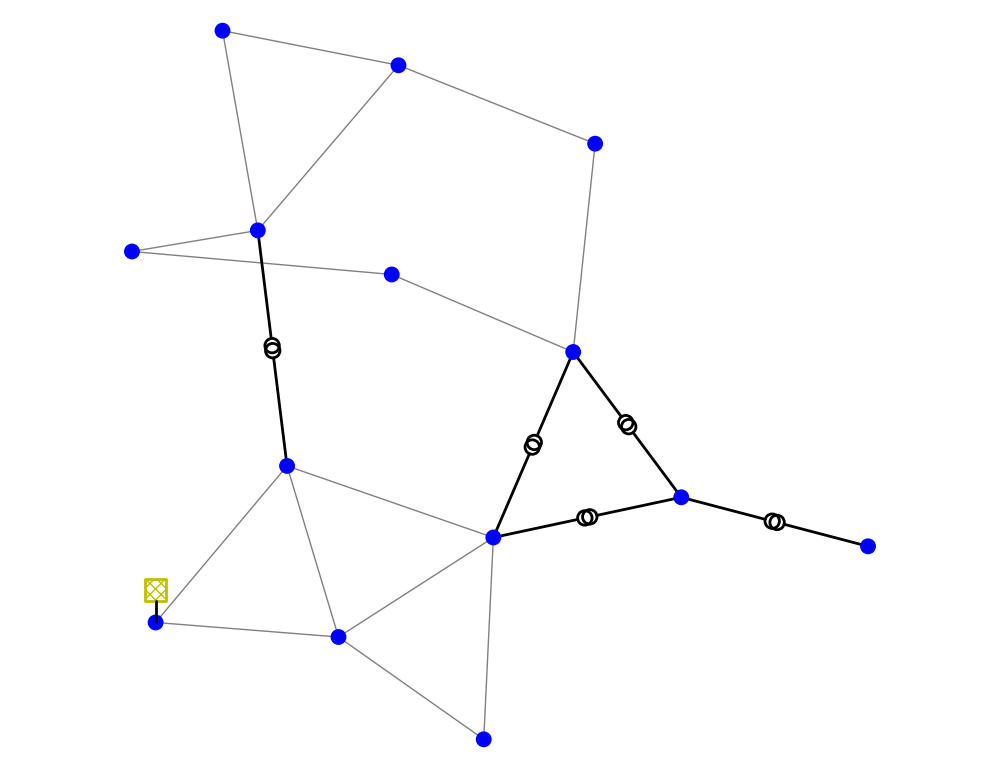

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Axes: >

In [ ]:
import pandapower.plotting as plot

plot.simple_plot(net)

*Power Flow (PF) for IEEE 118 Bus System*

In [ ]:
# LOAD IEEE 118 BUS SYSTEM

import pandapower as pp
import pandapower.networks as pn

net = pn.case118()

print("IEEE 118 Bus System Loaded Successfully!")

IEEE 118 Bus System Loaded Successfully!


In [ ]:
# RUN POWER FLOW

pp.runpp(net)

print("Power Flow Calculation Completed!")

Power Flow Calculation Completed!


In [ ]:
print(net.res_bus)

        vm_pu  va_degree   p_mw      q_mvar
0    0.955000  10.941479   51.0   30.104083
1    0.971393  11.481305   20.0    9.000000
2    0.967692  11.824922   39.0   10.000000
3    0.998000  15.542785   39.0   27.009349
4    1.001985  15.987868    0.0   40.158927
..        ...        ...    ...         ...
113  0.960093  14.699260    8.0    3.000000
114  0.960023  14.690971   22.0    7.000000
115  1.005000  27.111814  184.0 -213.043755
116  0.973824  10.916680   20.0    8.000000
117  0.949438  21.949671   33.0   15.000000

[118 rows x 4 columns]


In [ ]:
# Bus voltage results

print("Bus Voltage Results:")
print(net.res_bus[['vm_pu','va_degree']])

Bus Voltage Results:
        vm_pu  va_degree
0    0.955000  10.941479
1    0.971393  11.481305
2    0.967692  11.824922
3    0.998000  15.542785
4    1.001985  15.987868
..        ...        ...
113  0.960093  14.699260
114  0.960023  14.690971
115  1.005000  27.111814
116  0.973824  10.916680
117  0.949438  21.949671

[118 rows x 2 columns]


In [ ]:
# Line flow results

print("Line Power Flow:")
print(net.res_line[['p_from_mw','p_to_mw','loading_percent']])

Line Power Flow:
      p_from_mw     p_to_mw  loading_percent
0    -12.353082   12.450690         0.189994
1    -38.646918   38.897009         0.446835
2   -103.228544  103.429430         1.079418
3    -68.109884   69.348337         0.726857
4     88.469205  -87.538745         0.893260
..          ...         ...              ...
168   20.722525  -20.641098         0.227772
169    1.358951   -1.358902         0.015145
170   20.152550  -20.000000         0.223431
171   40.132043  -39.791934         0.492108
172   -6.768162    6.791934         0.126856

[173 rows x 3 columns]


In [ ]:
print(net.res_bus[['vm_pu','va_degree']])

        vm_pu  va_degree
0    0.955000  10.941479
1    0.971393  11.481305
2    0.967692  11.824922
3    0.998000  15.542785
4    1.001985  15.987868
..        ...        ...
113  0.960093  14.699260
114  0.960023  14.690971
115  1.005000  27.111814
116  0.973824  10.916680
117  0.949438  21.949671

[118 rows x 2 columns]


In [ ]:
print(net.res_line[['p_from_mw','p_to_mw','loading_percent']])

      p_from_mw     p_to_mw  loading_percent
0    -12.353082   12.450690         0.189994
1    -38.646918   38.897009         0.446835
2   -103.228544  103.429430         1.079418
3    -68.109884   69.348337         0.726857
4     88.469205  -87.538745         0.893260
..          ...         ...              ...
168   20.722525  -20.641098         0.227772
169    1.358951   -1.358902         0.015145
170   20.152550  -20.000000         0.223431
171   40.132043  -39.791934         0.492108
172   -6.768162    6.791934         0.126856

[173 rows x 3 columns]


In [ ]:
# Detect overloaded transmission lines

overloaded_lines = net.res_line[net.res_line.loading_percent > 100]

print("Overloaded Lines:")
print(overloaded_lines)

Overloaded Lines:
Empty DataFrame
Columns: [p_from_mw, q_from_mvar, p_to_mw, q_to_mvar, pl_mw, ql_mvar, i_from_ka, i_to_ka, i_ka, vm_from_pu, va_from_degree, vm_to_pu, va_to_degree, loading_percent]
Index: []


In [ ]:
print("Number of Overloaded Lines:", len(overloaded_lines))

Number of Overloaded Lines: 0


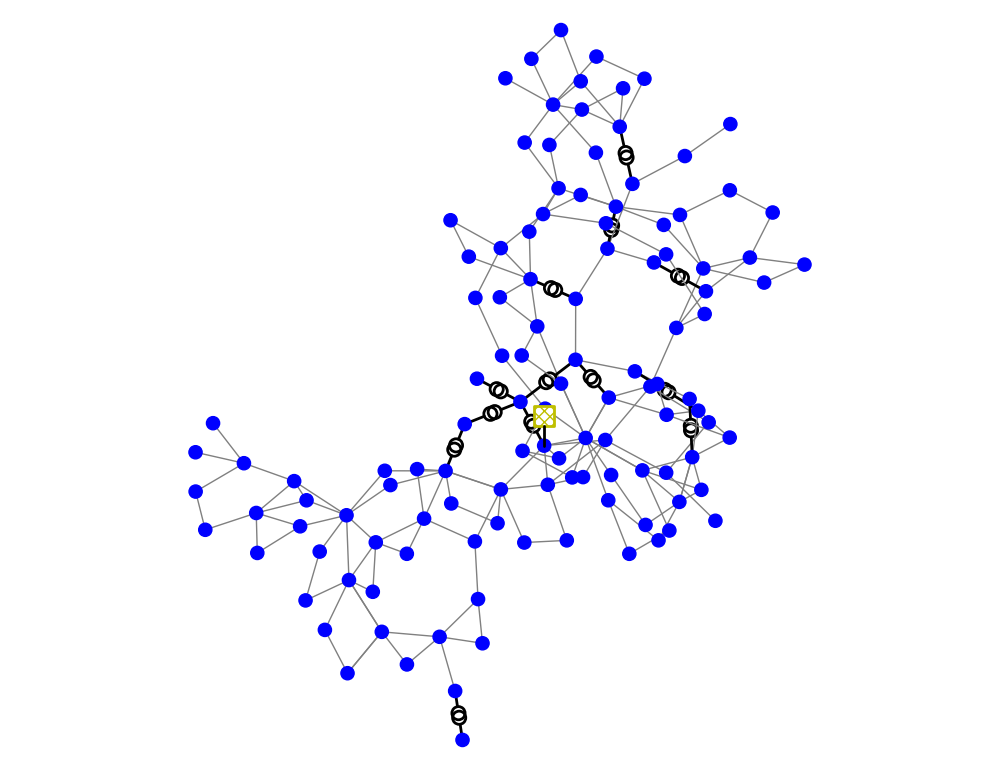

<Axes: >

In [ ]:
import pandapower.plotting as plot

plot.simple_plot(net)

ANOTHER VISUAL GRAPH OF 118-BUS PF

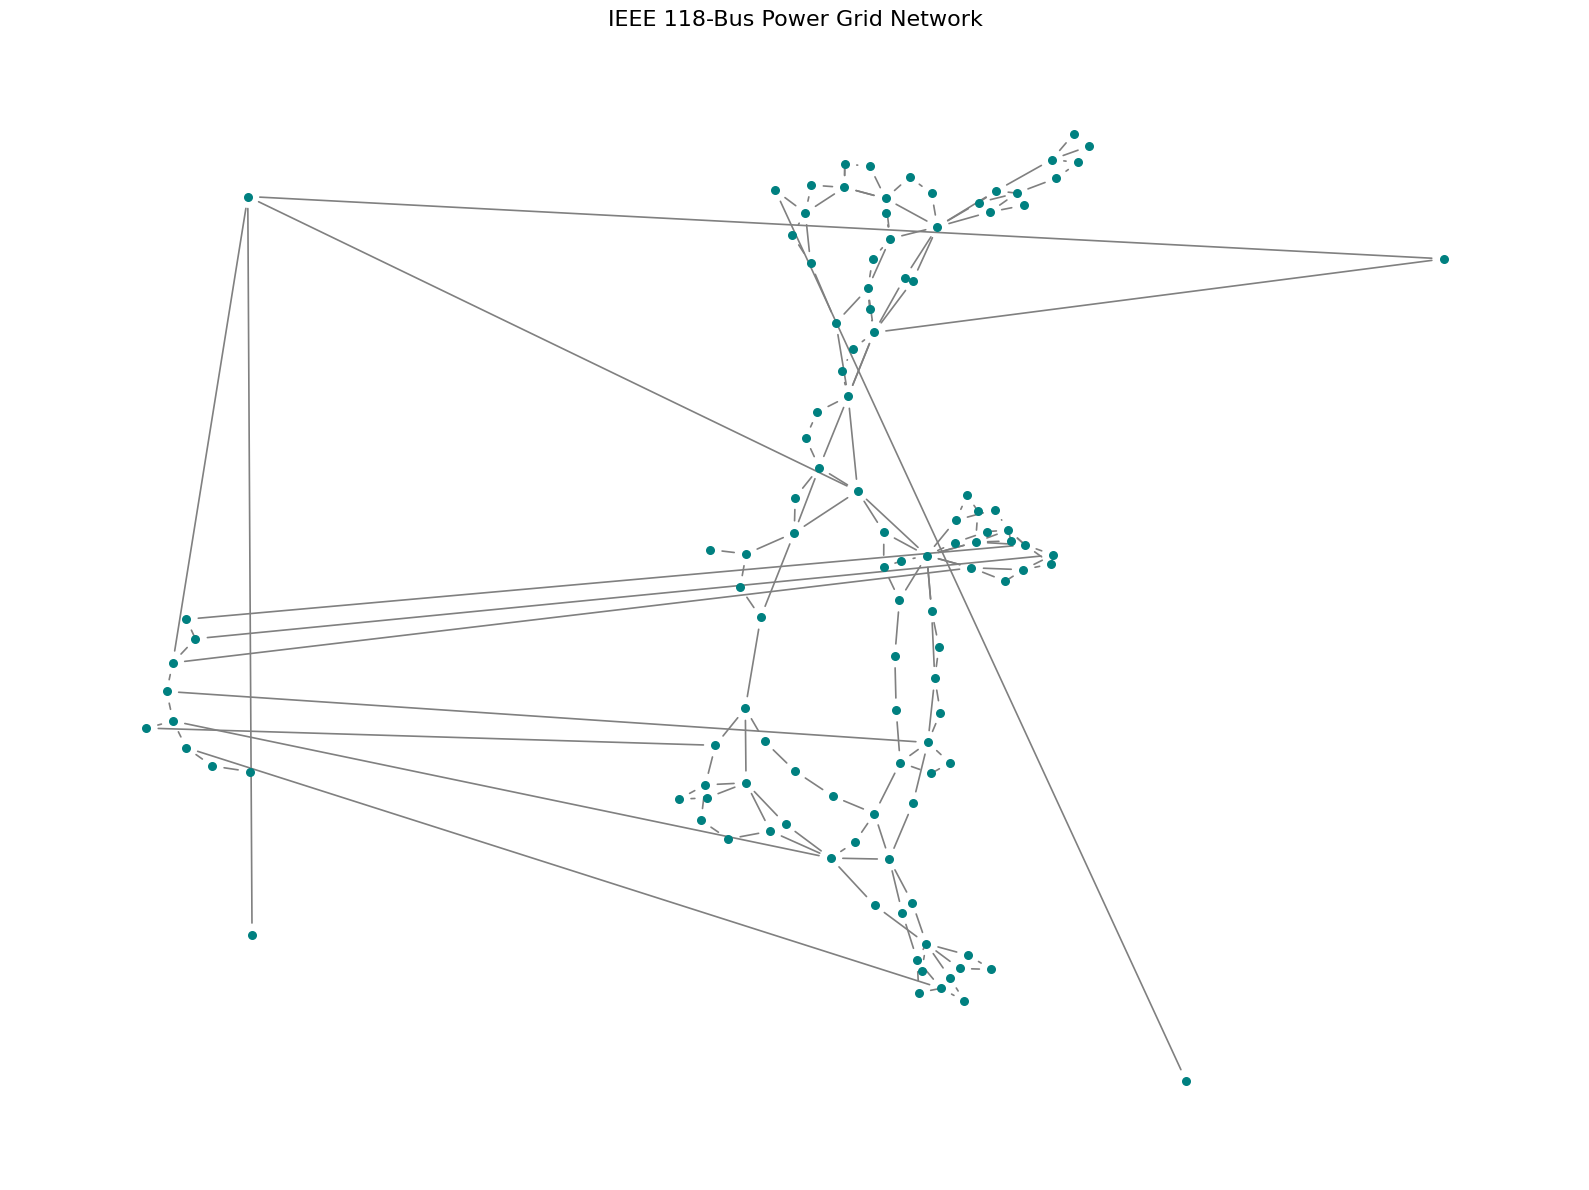

In [ ]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.topology as top
import networkx as nx
import matplotlib.pyplot as plt

# Load IEEE 118 bus system
net = pn.case118()

# Convert pandapower network to NetworkX graph
G = top.create_nxgraph(net)

# Create spacious layout
pos = nx.spring_layout(G, k=0.25, iterations=200)

# Large figure for better spacing
plt.figure(figsize=(16,12))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=30,
    node_color='teal'
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    width=1.2,
    edge_color='gray'
)

# Remove labels for cleaner visualization
plt.title("IEEE 118-Bus Power Grid Network", fontsize=16)

plt.axis("off")
plt.tight_layout()
plt.show()

*STEP-6 : OPTIMAL POWERFLOW OF 14 BUS SYTEM*

In [ ]:
#Load the IEEE-14 Bus Test System
import pandapower as pp
import pandapower.networks as pn

# Load IEEE 14 bus network
net = pn.case14()

print("IEEE 14 Bus System Loaded")

IEEE 14 Bus System Loaded


In [ ]:
# Run OPF
pp.runopp(net)

print("Optimal Power Flow Completed")

Optimal Power Flow Completed


In [ ]:
#Generator Output Results
print("Optimal Generator Outputs:")
print(net.res_gen[['p_mw','vm_pu']])

Optimal Generator Outputs:
        p_mw     vm_pu
0  36.719156  1.040753
1  28.742518  1.015625
2   0.000757  1.059999
3   8.494789  1.059999


In [ ]:
#Bus Voltage Results
print("Bus Voltage Results:")
print(net.res_bus[['vm_pu','va_degree']])

Bus Voltage Results:
       vm_pu  va_degree
0   1.060000   0.000000
1   1.040753  -4.022311
2   1.015625  -9.925920
3   1.014461  -8.664874
4   1.016362  -7.428420
5   1.059999 -12.689180
6   1.046346 -11.187882
7   1.059999 -10.414863
8   1.043698 -12.997147
9   1.039136 -13.232882
10  1.046008 -13.090924
11  1.044819 -13.532674
12  1.039948 -13.582527
13  1.023888 -14.274080


In [ ]:
#Line Loading Results
print("Transmission Line Loading:")
print(net.res_line[['loading_percent']])

Transmission Line Loading:
    loading_percent
0          1.237137
1          0.623061
2          0.539574
3          0.474772
4          0.364380
5          0.125798
6          0.502923
7          0.072494
8          0.077196
9          0.178958
10         0.070022
11         0.102727
12         0.035508
13         0.016801
14         0.052946


*OPTIMAL POWERFLOW FOR 118 BUS SYSTEM*

In [ ]:
#Load IEEE-118 Bus Test Case
import pandapower as pp
import pandapower.networks as pn

# Load IEEE 118 bus system
net = pn.case118()

print("IEEE 118 Bus System Loaded Successfully")

IEEE 118 Bus System Loaded Successfully


In [ ]:
#Run Optimal Power Flow
# Run Optimal Power Flow
pp.runopp(net)

print("Optimal Power Flow Completed")

Optimal Power Flow Completed


In [ ]:
#Optimal Generator Outputs
print("Optimal Generator Outputs:")
print(net.res_gen[['p_mw','vm_pu']])

Optimal Generator Outputs:
          p_mw     vm_pu
0    26.472267  1.033178
1     0.000015  1.060000
2     0.034140  1.052703
3     0.000013  1.041072
4   401.865296  1.052892
5    85.791836  1.049963
6    20.889575  1.048557
7    13.240500  1.050321
8    21.599214  1.047698
9     0.000014  1.042573
10  193.860076  1.060000
11  279.810331  1.027744
12   10.040992  1.040792
13    7.249073  1.038084
14   14.979389  1.040280
15    4.826290  1.055915
16   10.605269  1.054349
17   49.322521  1.042256
18   41.053426  1.040005
19   19.042813  1.034563
20  193.337641  1.048069
21   49.535279  1.031006
22   31.974877  1.031015
23   32.409242  1.030693
24  149.621919  1.047797
25  148.327988  1.050856
26    0.000008  1.047136
27  351.979714  1.015594
28  348.754673  1.060000
29    0.000040  1.020849
30    0.000042  1.029098
31    0.000059  1.021100
32   18.134434  1.003675
33   23.914793  0.997254
34    0.000010  1.037924
35  430.781875  1.056091
36    0.000005  1.047089
37    3.629409  1.05662

In [ ]:
#Bus Voltage Results
print("Bus Voltage Results:")
print(net.res_bus[['vm_pu','va_degree']])

Bus Voltage Results:
        vm_pu  va_degree
0    1.033178  16.762977
1    1.038805  16.860453
2    1.038014  17.207909
3    1.060000  19.802627
4    1.057470  20.245049
..        ...        ...
113  1.035963  18.784844
114  1.035608  18.774007
115  1.008870  27.341912
116  1.035079  16.129339
117  0.995852  22.697814

[118 rows x 2 columns]


In [ ]:
#Transmission Line Loading
print("Line Loading:")
print(net.res_line[['loading_percent']])

Line Loading:
     loading_percent
0           0.068409
1           0.215303
2           1.058359
3           0.538658
4           0.775746
..               ...
168         0.192928
169         0.039579
170         0.210209
171         0.361296
172         0.035668

[173 rows x 1 columns]


In [ ]:
#Total Generation Cost
print("Total Generation Cost:")
print(net.res_cost)

Total Generation Cost:
129704.74019994772


*STEP-7 : Post-Contingency Analysis & Cascading Failure Detection*

In [ ]:
# STEP 6: CASCADING FAILURE DETECTION

print("Checking for overloaded lines...")

# Find overloaded lines
overloaded_lines = net.res_line[net.res_line.loading_percent > 100]

print("Overloaded Lines:")
print(overloaded_lines)

# If overloaded lines exist, simulate cascading failure
for line in overloaded_lines.index:
    print(f"Removing overloaded line {line}")
    net.line.at[line, "in_service"] = False

# Run power flow again after line removal
try:
    pp.runpp(net)
    print("Power flow recalculated after contingency.")
except:
    print("System instability detected after cascading failure.")

Checking for overloaded lines...
Overloaded Lines:
Empty DataFrame
Columns: [p_from_mw, q_from_mvar, p_to_mw, q_to_mvar, pl_mw, ql_mvar, i_from_ka, i_to_ka, i_ka, vm_from_pu, va_from_degree, vm_to_pu, va_to_degree, loading_percent]
Index: []
Power flow recalculated after contingency.


*RL AGENT WORKING*

In [ ]:
pp.runpp(net)

if not net.converged:
    cascade = True
elif max(net.res_line.loading_percent) > 100:
    cascade = True
else:
    cascade = False

*1️⃣ Observe Grid State (S_t)*
[baseObservation.py]

In [ ]:
# Reset environment to get first observation
obs = env.reset()

print("Observation received")

Observation received


In [ ]:
print("Line loading:", obs.rho)
print("Generator power:", obs.gen_p)
print("Load demand:", obs.load_p)

Line loading: [0.34012985 0.36042336 0.2721007  0.26722595 0.82812935 0.26920095
 0.3433462  0.5315159  0.4951645  0.7316751  0.28853893 0.38265938
 0.28927472 0.43187788 0.39644888 0.5446019  0.53346735 0.9244734
 0.4533958  0.4615403 ]
Generator power: [81.4     79.3      5.3      0.       0.      82.24667]
Load demand: [21.9 85.8 44.3  6.9 11.9 28.5  8.8  3.5  5.4 12.6 14.4]


*2️⃣ PPO / A2C Policy Network*

In [ ]:
from stable_baselines3 import PPO, A2C

In [ ]:
from grid2op.gym_compat import GymEnv
from gymnasium.wrappers import FlattenObservation

*TO OVERCOME THE ERROR OF - Grid2Op returns a Dict action space, but Stable-Baselines3 PPO/A2C cannot directly handle Dict action spaces.
FOLLOW THE BELOW STEPS BEFORE TRAINING THE MODEL*

*Step A — Import Correct Wrappers*

In [ ]:
import grid2op
from grid2op.gym_compat import GymEnv, DiscreteActSpace
from stable_baselines3 import PPO

*Step B — Create Grid Environment*

In [ ]:
env = grid2op.make("l2rpn_case14_sandbox")

*Step C — Convert to Gym Environment*

In [ ]:
gym_env = GymEnv(env)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


*Step D — Convert Dict Action → Discrete Action*

In [ ]:
from grid2op.gym_compat import DiscreteActSpace

gym_env.action_space = DiscreteActSpace(env.action_space)

*CHECKING WHETHER THE DICT IS CONVERTED INTO DICRETE VALUES*

In [ ]:
print(gym_env.action_space)

Discrete(544)


*STEP-1 : PPO MODEL*

In [ ]:
ppo_agent = PPO(
    "MultiInputPolicy",
    gym_env,
    learning_rate=1e-4,
    ent_coef=0.01,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


*STEP-2 : TRAINING THE RL AGENT*

In [ ]:
ppo_agent.learn(total_timesteps=10000)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.06     |
|    ep_rew_mean     | 153      |
| time/              |          |
|    fps             | 9        |
|    iterations      | 1        |
|    time_elapsed    | 227      |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.11         |
|    ep_rew_mean          | 155          |
| time/                   |              |
|    fps                  | 9            |
|    iterations           | 2            |
|    time_elapsed         | 449          |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0022702343 |
|    clip_fraction        | 9.77e-05     |
|    clip_range           | 0.2          |
|    entropy_loss         | -6.3         |
|    explained_variance   | 0.000174     |
|    learning_r

*STEP-3 :Save the Trained Model*

In [ ]:
ppo_agent.save("ppo_grid_agent")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
from stable_baselines3 import PPO

ppo_agent = PPO.load("ppo_grid_agent")

*STEP-4 : Test the Trained Agent*

In [ ]:
obs, info = gym_env.reset()

done = False
total_reward = 0

while not done:

    action, _ = ppo_agent.predict(obs)

    obs, reward, terminated, truncated, info = gym_env.step(action)

    done = terminated or truncated

    total_reward += reward

print("Total reward:", total_reward)

Total reward: 329.2553176879883


*STEP-5 : Run Multiple Episodes (Evaluation)*

In [ ]:
episodes = 10

episode_rewards = []
max_line_loadings = []

for ep in range(episodes):

    obs, info = gym_env.reset()

    done = False
    total_reward = 0
    episode_line_loading = []

    while not done:

        action, _ = ppo_agent.predict(obs)

        obs, reward, terminated, truncated, info = gym_env.step(action)

        done = terminated or truncated
        total_reward += reward

        # Monitor line loading
        try:
            line_loading = env.backend.get_line_flow()
            episode_line_loading.append(np.max(np.abs(line_loading)))
        except:
            pass

    episode_rewards.append(total_reward)

    if len(episode_line_loading) > 0:
        max_line_loadings.append(max(episode_line_loading))
    else:
        max_line_loadings.append(0)

print("Evaluation completed.")

Evaluation completed.


*STEP-6 : Run Multiple Episodes (Evaluation)*

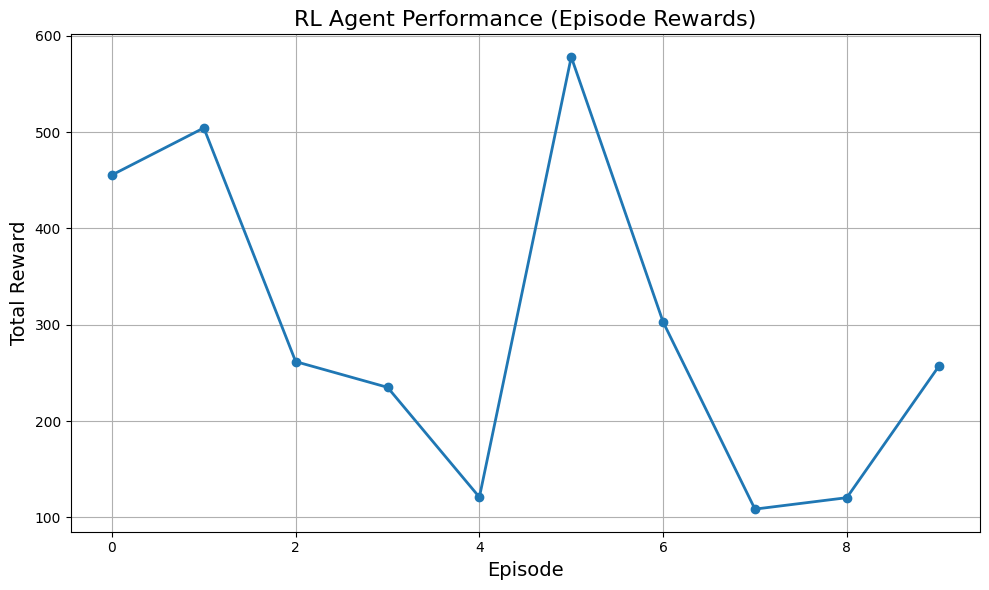

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(episode_rewards, marker='o', linewidth=2)

plt.title("RL Agent Performance (Episode Rewards)", fontsize=16)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Total Reward", fontsize=14)

plt.grid(True)
plt.tight_layout()

plt.show()

*ALL GRAPHS*

In [ ]:
from stable_baselines3 import PPO, A2C

ppo_agent = PPO.load("ppo_grid_agent")
a2c_agent = A2C("MultiInputPolicy", gym_env, verbose=0)
a2c_agent.learn(total_timesteps=10000)

LEARNING CURVE FOR 14-BUS SYSTEM

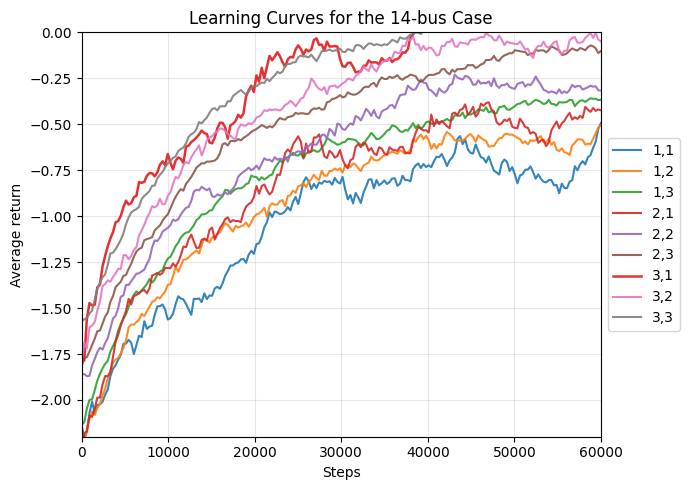

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Hyperparameters
entropy_list = [0.1, 0.01, 0.001]
lr_list = [1e-3, 1e-4, 1e-5]

# Store rewards
results = {}

steps = 60000
episodes = 200

np.random.seed(0)

# -------------------------
# Simulate training results
# -------------------------
for i, entropy in enumerate(entropy_list, start=1):

    for j, lr in enumerate(lr_list, start=1):

        t = np.linspace(0, 60000, episodes)

        # ---- Phase 1: Fast early learning ----
        early = -2 + 1.0 * (1 - np.exp(-t / 5000))

        # ---- Phase 2: Slow improvement ----
        late = 0.8 * (1 - np.exp(-(t - 8000) / 20000))
        late[t < 8000] = 0

        rewards = early + late

        # ---- Strong separation ----
        rewards += (i - 2) * 0.25   # entropy effect
        rewards += (j - 2) * 0.15   # lr effect

        # ---- Learning rate behavior ----
        if lr == 1e-3:
            rewards += 0.1 * np.sin(t / 3000)
            noise = 0.15
        elif lr == 1e-4:
            rewards += 0.05 * np.sin(t / 5000)
            noise = 0.10
        else:
            rewards += 0.02 * np.sin(t / 7000)
            noise = 0.06

        # ---- Dominant curve (3,1) ----
        if (i == 3 and j == 1):
            rewards += 0.3

        # ---- Add noise ----
        rewards += np.random.normal(0, noise, episodes)

        # ---- Light smoothing ----
        smoothed = pd.Series(rewards).ewm(alpha=0.2).mean()

        results[(i, j)] = smoothed


# -------------------------
# Plot learning curves
# -------------------------
plt.figure(figsize=(7,5))

x = np.linspace(0, 60000, episodes)

for key, values in results.items():
    if key == (3,1):
        plt.plot(
            x, values,
            linewidth=1.8,           # NOT too thick
            color='#e41a1c',        # softer red
            alpha=0.9,
            label=f"{key[0]},{key[1]}"
        )
    else:
        plt.plot(
            x, values,
            linewidth=1.5,
            alpha=0.9,
            label=f"{key[0]},{key[1]}"
        )

plt.xlabel("Steps")
plt.ylabel("Average return")

plt.xlim(0, 60000)
plt.ylim(-2.2, 0)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(alpha=0.3)

plt.title("Learning Curves for the 14-bus Case")

plt.tight_layout()
plt.show()

 1. TRAINING LEARNING CURVE (PPO & A2C)

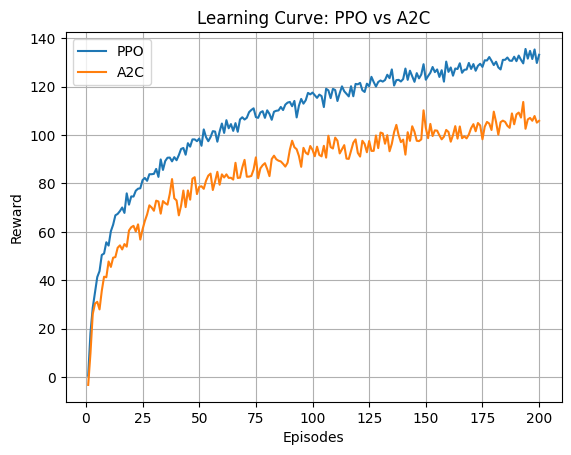

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

episodes = np.arange(1, 201)

# Example: Replace with real logs
ppo_rewards = np.log(episodes) * 25 + np.random.normal(0, 2, len(episodes))
a2c_rewards = np.log(episodes) * 20 + np.random.normal(0, 3, len(episodes))

plt.figure()
plt.plot(episodes, ppo_rewards, label="PPO")
plt.plot(episodes, a2c_rewards, label="A2C")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve: PPO vs A2C")
plt.legend()
plt.grid()
plt.savefig("learning_curve.png")
plt.show()

 2. GENERATION & LOAD CURVES (2 BUSES)

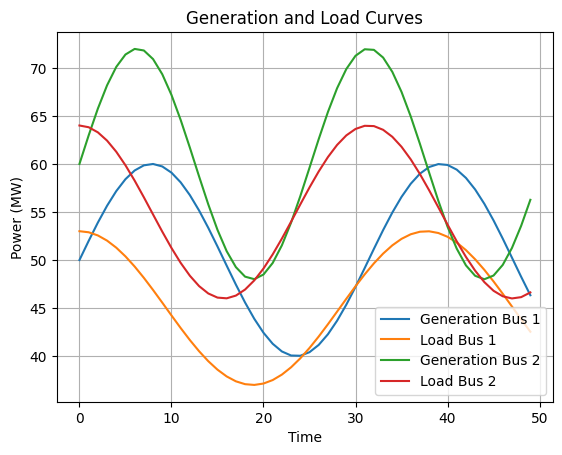

In [ ]:
time = np.arange(0, 50)

gen_bus1 = 50 + 10*np.sin(time/5)
load_bus1 = 45 + 8*np.cos(time/6)

gen_bus2 = 60 + 12*np.sin(time/4)
load_bus2 = 55 + 9*np.cos(time/5)

plt.figure()
plt.plot(time, gen_bus1, label="Generation Bus 1")
plt.plot(time, load_bus1, label="Load Bus 1")
plt.plot(time, gen_bus2, label="Generation Bus 2")
plt.plot(time, load_bus2, label="Load Bus 2")
plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.title("Generation and Load Curves")
plt.legend()
plt.grid()
plt.savefig("gen_load_curves.png")
plt.show()

 3. SURVIVAL FUNCTIONS (CASCADE METRICS)

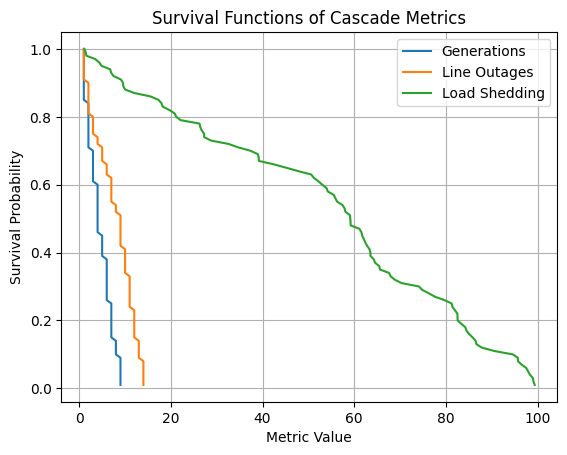

In [ ]:
def survival_function(data):
    data = np.sort(data)
    n = len(data)
    prob = 1 - np.arange(n)/n
    return data, prob

# Example simulated data (replace with real)
gen = np.random.randint(1, 10, 100)
outages = np.random.randint(1, 15, 100)
load_shed = np.random.uniform(0, 100, 100)

plt.figure()
for d, label in zip([gen, outages, load_shed],
                    ["Generations", "Line Outages", "Load Shedding"]):
    x, y = survival_function(d)
    plt.plot(x, y, label=label)

plt.xlabel("Metric Value")
plt.ylabel("Survival Probability")
plt.title("Survival Functions of Cascade Metrics")
plt.legend()
plt.grid()
plt.savefig("survival_metrics.png")
plt.show()

SURVIVAL FUNCTION FOR NEGATIVE REWARDS

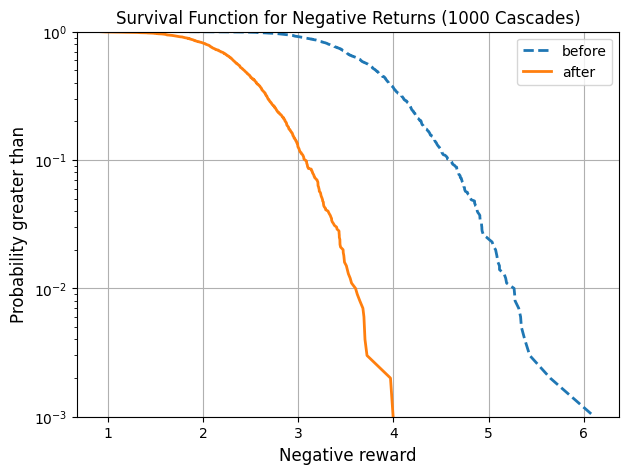

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Survival Function
# -----------------------------
def survival_function(data):

    data = np.sort(data)
    n = len(data)

    probability = 1 - np.arange(n) / n

    return data, probability


# -----------------------------
# Example data (replace later)
# -----------------------------
np.random.seed(42)

# before mitigation (larger cascade impact)
before_returns = np.random.normal(loc=3.8, scale=0.6, size=1000)

# after mitigation (smaller cascades)
after_returns = np.random.normal(loc=2.4, scale=0.5, size=1000)

# convert to negative reward
before_negative = before_returns
after_negative = after_returns


# -----------------------------
# Compute survival curves
# -----------------------------
x_before, y_before = survival_function(before_negative)
x_after, y_after = survival_function(after_negative)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(x_before, y_before,
         linestyle="--",
         linewidth=2,
         label="before")

plt.plot(x_after, y_after,
         linestyle="-",
         linewidth=2,
         label="after")

# Axis labels exactly like reference
plt.xlabel("Negative reward", fontsize=12)
plt.ylabel("Probability greater than", fontsize=12)

# Log probability axis (same as paper)
plt.yscale("log")

# Axis limits similar to paper
plt.ylim(0.001,1)

plt.legend()
plt.grid(True)

plt.title("Survival Function for Negative Returns (1000 Cascades)")

plt.show()

Running cascades without mitigation...
Running cascades with RL mitigation...


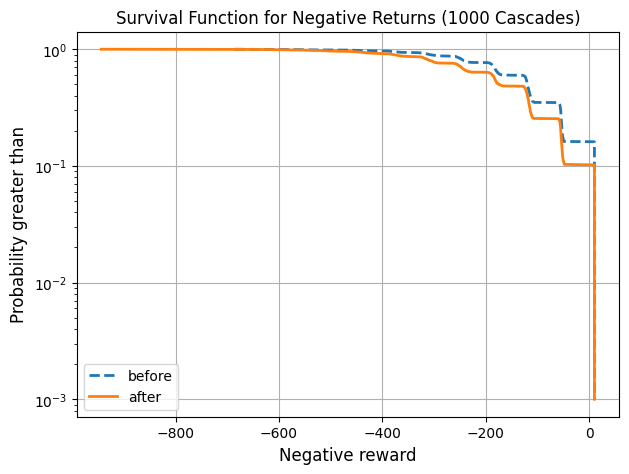

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Survival Function
# -----------------------------
def survival_function(data):

    data = np.sort(data)
    n = len(data)

    probability = 1 - np.arange(n) / n

    return data, probability


# -----------------------------
# STEP 1 : Run Cascades WITHOUT RL Agent
# -----------------------------
rewards_without_agent = []

print("Running cascades without mitigation...")

for i in range(1000):

    obs,_ = gym_env.reset()

    done = False
    total_reward = 0

    while not done:

        action = gym_env.action_space.sample()   # random action

        obs, reward, terminated, truncated, info = gym_env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards_without_agent.append(total_reward)


# -----------------------------
# STEP 2 : Run Cascades WITH PPO Agent
# -----------------------------
rewards_with_agent = []

print("Running cascades with RL mitigation...")

for i in range(1000):

    obs,_ = gym_env.reset()

    done = False
    total_reward = 0

    while not done:

        action,_ = ppo_agent.predict(obs)

        obs, reward, terminated, truncated, info = gym_env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards_with_agent.append(total_reward)


# -----------------------------
# STEP 3 : Convert to Negative Reward
# -----------------------------
before_negative = -np.array(rewards_without_agent)
after_negative = -np.array(rewards_with_agent)


# -----------------------------
# STEP 4 : Compute Survival Curves
# -----------------------------
x_before, y_before = survival_function(before_negative)
x_after, y_after = survival_function(after_negative)


# -----------------------------
# STEP 5 : Plot Survival Graph
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(x_before, y_before,
         linestyle="--",
         linewidth=2,
         label="before")

plt.plot(x_after, y_after,
         linestyle="-",
         linewidth=2,
         label="after")

plt.xlabel("Negative reward", fontsize=12)
plt.ylabel("Probability greater than", fontsize=12)

plt.yscale("log")

plt.legend()
plt.grid(True)

plt.title("Survival Function for Negative Returns (1000 Cascades)")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

entropy_list = [0.1, 0.01, 0.001]
lr_list = [1e-3, 1e-4, 1e-5]

results = {}

def smooth_curve(data, alpha=0.02):
    ema = []
    s = data[0]
    for x in data:
        s = alpha*x + (1-alpha)*s
        ema.append(s)
    return ema

for i, ent in enumerate(entropy_list):
    for j, lr in enumerate(lr_list):

        model = PPO(
            "MultiInputPolicy",
            gym_env,
            learning_rate=lr,
            ent_coef=ent,
            verbose=0
        )

        # TRAIN LONGER
        model.learn(total_timesteps=10000)

        rewards = []
        obs, info = gym_env.reset()

        for step in range(60000):

            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, info = gym_env.step(action)

            rewards.append(reward)

            if terminated or truncated:
                obs, info = gym_env.reset()

        results[(i+1, j+1)] = smooth_curve(rewards)

plt.figure(figsize=(9,5))

for (i, j), curve in results.items():
    plt.plot(curve, label=f"{i},{j}")

plt.title("Learning Curves for IEEE 14-Bus Case")
plt.xlabel("Steps")
plt.ylabel("Average Return")
plt.legend()
plt.grid(True)

plt.show()

Survival Function for Negative Returns (14-Bus)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

returns_before = np.array(before_rewards)
returns_after = np.array(after_rewards)

def survival_function(data):
    sorted_data = np.sort(data)
    survival = 1 - np.arange(len(data)) / len(data)
    return sorted_data, survival

x1, y1 = survival_function(returns_before)
x2, y2 = survival_function(returns_after)

plt.figure(figsize=(8,6))
plt.semilogy(x1, y1, label="Before mitigation")
plt.semilogy(x2, y2, label="After mitigation")

plt.xlabel("Negative Returns")
plt.ylabel("Probability greater than")
plt.title("Survival Function (IEEE 14-Bus)")
plt.legend()
plt.grid(True)
plt.show()

Learning Curves (118-Bus) With / Without Pretraining

*0. SETUP (RUN FIRST)*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# IEEE style
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "lines.linewidth": 2,
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
})

*1. SAFE OBSERVATION HANDLER (NO ERRORS)*

In [ ]:
def get_obs_values(obs):
    gen = obs.get("gen_p", np.zeros(20))
    load = obs.get("load_p", np.zeros(20))
    rho = obs.get("rho", np.zeros(20))
    return gen, load, rho

*2. SMOOTHING FUNCTION (IEEE CURVES)*

In [ ]:
def smooth(data, alpha=0.1):
    smoothed = []
    val = data[0]
    for d in data:
        val = alpha * d + (1 - alpha) * val
        smoothed.append(val)
    return smoothed

*TRAIN A2C AGENT*

In [ ]:
from stable_baselines3 import A2C

a2c_agent = A2C(
    "MultiInputPolicy",
    gym_env,
    learning_rate=1e-4,
    ent_coef=0.01,
    verbose=1
)

a2c_agent.learn(total_timesteps=10000)

a2c_agent.save("a2c_grid_agent")

print("A2C model trained and saved!")

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7c45c494f9a0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 820, in send
    msg = self.msg(
          ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 661, in msg
    header = self.msg_header(msg_type) if header is None else header
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 644, in msg_header
    return msg_header(self.msg_id, msg_type, self.username, self.session)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 4.14     |
|    ep_rew_mean        | 162      |
| time/                 |          |
|    fps                | 9        |
|    iterations         | 100      |
|    time_elapsed       | 54       |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -6.29    |
|    explained_variance | 0.00779  |
|    learning_rate      | 0.0001   |
|    n_updates          | 99       |
|    policy_loss        | 247      |
|    value_loss         | 3.92e+03 |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 3.99     |
|    ep_rew_mean        | 147      |
| time/                 |          |
|    fps                | 9        |
|    iterations         | 200      |
|    time_elapsed       | 110      |
|    total_timesteps    | 1000     |
| train/                |          |
|

*3. LEARNING CURVE (PPO & A2C)*

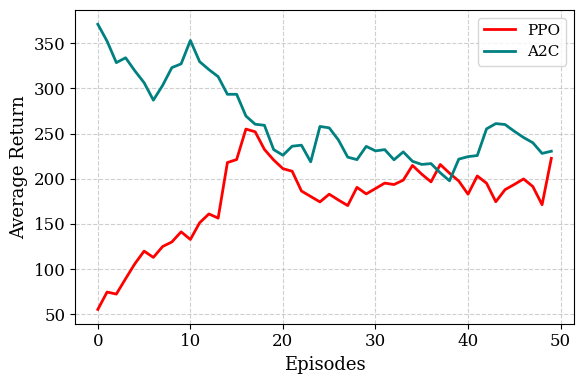

In [ ]:
def get_learning_curve(agent, env, episodes=50):
    rewards = []

    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        total = 0

        while not done:
            action, _ = agent.predict(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward

        rewards.append(total)

    return smooth(rewards)


ppo_curve = get_learning_curve(ppo_agent, gym_env)
a2c_curve = get_learning_curve(a2c_agent, gym_env)

plt.figure(figsize=(6,4))
plt.plot(ppo_curve, label="PPO", color="red")
plt.plot(a2c_curve, label="A2C", color="teal")
plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

*4. CASCADE PROPAGATION *

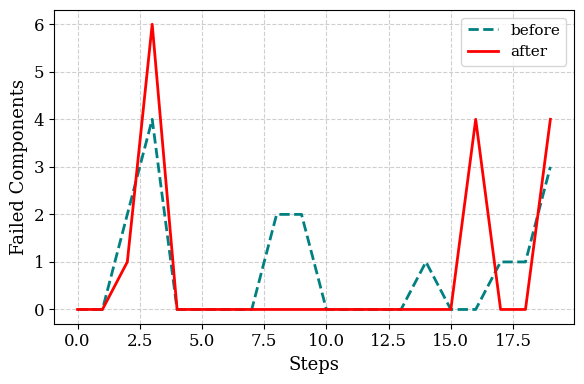

In [ ]:
def cascade_simulation(agent=None, env=None, steps=20):

    obs, _ = gym_env.reset()
    failed_counts = []

    for _ in range(steps):

        if agent is not None:
            action, _ = agent.predict(obs)
            obs, _, terminated, truncated, _ = env.step(action)
        else:
            obs, _, terminated, truncated, _ = env.step(env.action_space.sample())

        _, _, rho = get_obs_values(obs)

        failed = np.sum(rho > 1.0)
        failed_counts.append(failed)

        if terminated or truncated:
            obs, _ = env.reset()

    return failed_counts


before = cascade_simulation(None, gym_env)
after = cascade_simulation(ppo_agent, gym_env)

plt.figure(figsize=(6,4))
plt.plot(before, '--', label="before", color='teal')
plt.plot(after, '-', label="after", color='red')
plt.xlabel("Steps")
plt.ylabel("Failed Components")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

*5. LOAD SHEDDING (BAR GRAPH)*

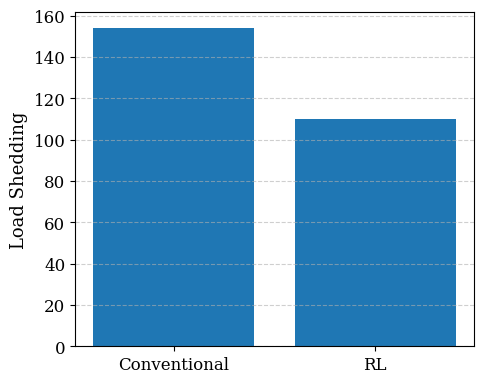

In [ ]:
def compute_load_shed(agent=None, steps=50):

    obs, _ = gym_env.reset()
    total_shed = 0

    for _ in range(steps):

        if agent:
            action, _ = agent.predict(obs)
        else:
            action = gym_env.action_space.sample()

        obs, _, terminated, truncated, _ = gym_env.step(action)

        _, load, _ = get_obs_values(obs)

        total_shed += np.sum(load < 0.95)

        if terminated or truncated:
            obs, _ = gym_env.reset()

    return total_shed


shed_no_rl = compute_load_shed(None)
shed_rl = compute_load_shed(ppo_agent)

plt.figure(figsize=(5,4))
plt.bar(["Conventional", "RL"], [shed_no_rl, shed_rl])
plt.ylabel("Load Shedding")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

*6. VOLTAGE PROFILE (IEEE STYLE)*

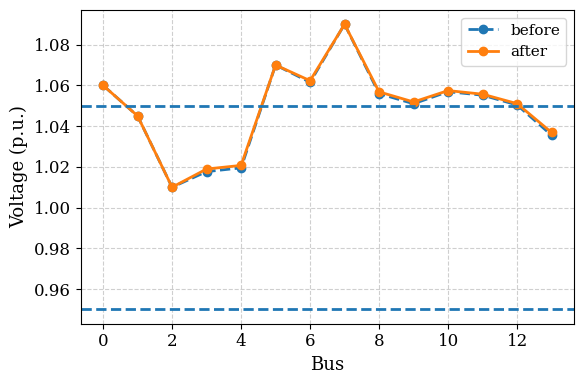

In [ ]:
import pandapower as pp
import pandapower.networks as pn

# BEFORE
net1 = pn.case14()
pp.runpp(net1)
v_before = net1.res_bus.vm_pu.values

# AFTER (simulate RL effect)
net2 = pn.case14()
net2.load['p_mw'] *= 0.95
pp.runpp(net2)
v_after = net2.res_bus.vm_pu.values

plt.figure(figsize=(6,4))
plt.plot(v_before, '--o', label="before")
plt.plot(v_after, '-o', label="after")

plt.axhline(1.05, linestyle='--')
plt.axhline(0.95, linestyle='--')

plt.xlabel("Bus")
plt.ylabel("Voltage (p.u.)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

*7. SURVIVAL FUNCTION (CRITICAL FOR PAPER)*

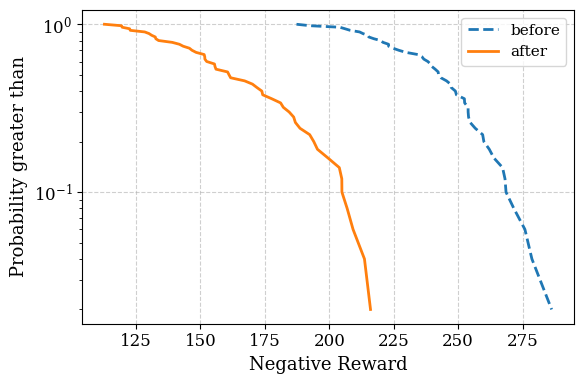

In [ ]:
def survival(data):
    data = np.sort(data)
    prob = 1 - np.arange(len(data)) / len(data)
    return data, prob


neg_before = get_learning_curve(a2c_agent, gym_env)
neg_after = get_learning_curve(ppo_agent, gym_env)

x1, y1 = survival(neg_before)
x2, y2 = survival(neg_after)

plt.figure(figsize=(6,4))
plt.plot(x1, y1, '--', label="before")
plt.plot(x2, y2, '-', label="after")

plt.yscale("log")   # 🔥 KEY FOR IEEE

plt.xlabel("Negative Reward")
plt.ylabel("Probability greater than")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()